# Setup

In [1]:
# Libs
import phobos
import numpy as np
import matplotlib.pyplot as plt
import time
from datetime import datetime
import pickle
from tqdm import tqdm
import serial
import serial.tools.list_ports as list_ports
import sys

✅ BMC lib found. Running in control mode.


In [2]:
# Constants
lam = 1550 # [nm]

In [3]:
def open_port():
    ports = list(list_ports.comports())

    dev_ii = -1
    if len(ports) == 0:
        print("Arduino board not detected")
        print("Connect Arduino board before starting the program")
        sys.exit()
    else:
        for ii, port in enumerate(ports):
            print(port)
            if "Arduino" in port.description:
                print("Found Arduino")
                dev_ii = ii
                break
        ser = serial.Serial(ports[dev_ii].device, 9600, timeout=1)
        time.sleep(1.0)
        return ser

def read_temp(ser):
    ser.flush()
    try:
        myread = ser.readline().decode('ascii').strip('\r\n')
    except:
        myread = -1

    return myread

In [4]:
test_probe = open_port()
print(read_temp(test_probe))
test_probe.close()

/dev/ttyS0 - ttyS0
/dev/ttyS1 - ttyS1
/dev/ttyUSBthorlabs - n/a
/dev/ttyUSBzaber - n/a
/dev/ttyUSBnewport - n/a
/dev/ttyUSB2 - CONEX-AGP - CONEX-AGP
/dev/ttyUSB1 - FW102CNEB - FW102CNEB
/dev/ttyUSB0 - FT232R USB UART - FT232R USB UART
/dev/ttyACM0 - Arduino Uno
Found Arduino
594
594


In [5]:
# shortcuts
dm = phobos.DM()
cam = phobos.Cred3()
chip = phobos.Arch6()
inj_seg = phobos.Config().get('injection.segments')
print('Injected segments:', inj_seg)

beam = 0
seg = inj_seg[beam]
print('Segment:', seg)

# Setup
path = phobos.archive.new('topa_power', verbose=True)


DEBUG - SDK Install Path: /opt/Boston Micromachines
DEBUG - BMC_PCIeOpenDM 27BW007#051 0
DEBUG - 1 BMC PCIe cards installed.
DEBUG - Using automatic devId: 1
DEBUG - BMC_PCIeOpenDM opening 0
INFO - PCIe HW Rev: 20000502
DEBUG - Loading map file: /opt/Boston Micromachines/Map/KILO507.map expected count: 1024
INFO - Loading calibration for DM: 27BW07#051_5_3_setof14
DEBUG - Loading map file: /opt/Boston Micromachines/Map/KILO507.map expected count: 1024
Cred3 camera initialized with dark subtraction
Injected segments: [138, 137, 136, 135]
Segment: 138
Archive created at /mnt/disk1/archive/2026-04-21_fdfc996/1_topa_power
INFO - Loading calibration for DM: 27BW07#051_5_3_setof14
DEBUG - Loading map file: /opt/Boston Micromachines/Map/KILO507.map expected count: 1024
Cred3 camera initialized with dark subtraction
Injected segments: [138, 137, 136, 135]
Segment: 138
Archive created at /mnt/disk1/archive/2026-04-21_fdfc996/1_topa_power


# Check cropping

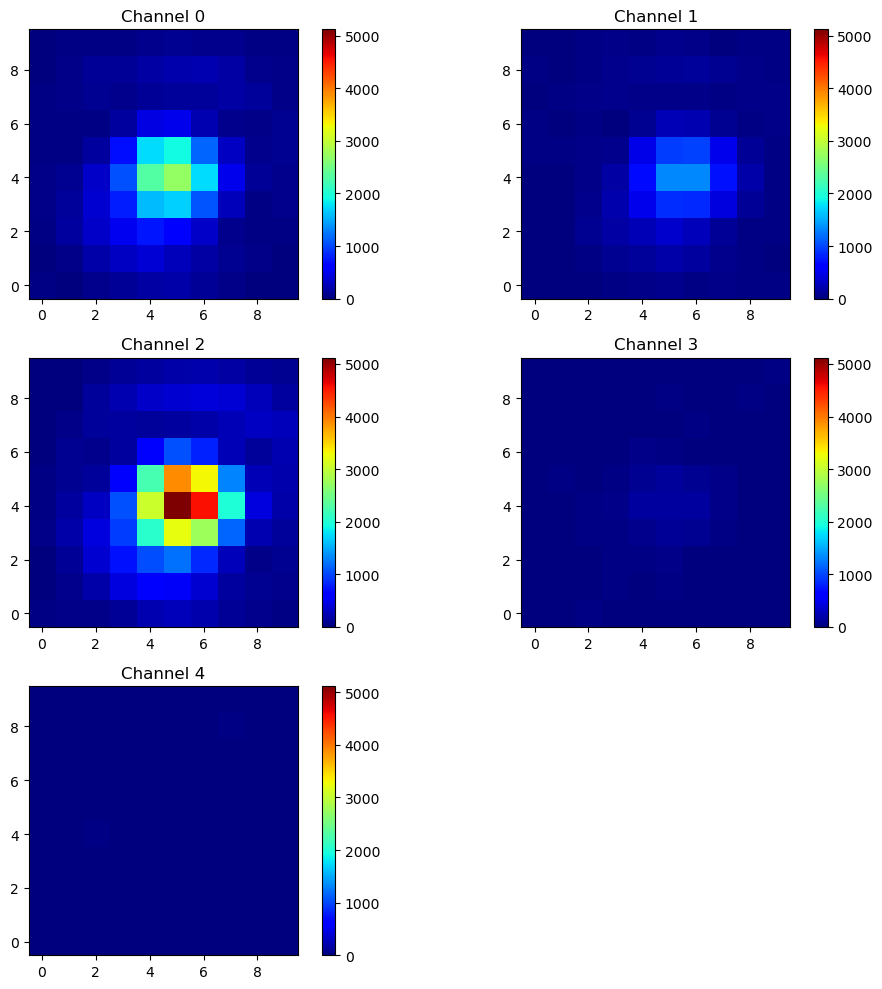

In [6]:
# check cropping
cam.check_cropping()

# Injection calibration

In [7]:
inj = phobos.Injection()
chip.turn_off()

Scanning injection maps:   0%|          | 0/4 [00:00<?, ?it/s]

  Channel 0 (segment 138): scanning…
Injection OFF on channels [1, 2, 3] (segments [137, 136, 135])


Scanning injection maps:  25%|██▌       | 1/4 [00:18<00:55, 18.48s/it]

Injection OFF on channels [0] (segments [138])
  Channel 1 (segment 137): scanning…
Injection OFF on channels [0, 2, 3] (segments [138, 136, 135])


Scanning injection maps:  50%|█████     | 2/4 [00:31<00:31, 15.54s/it]

...

Scanning injection maps:  75%|███████▌  | 3/4 [00:46<00:15, 15.12s/it]

Injection OFF on channels [2] (segments [136])
  Channel 3 (segment 135): scanning…
Injection OFF on channels [0, 1, 2] (segments [138, 137, 136])


Scanning injection maps: 100%|██████████| 4/4 [01:03<00:00, 15.84s/it]

Injection OFF on channels [3] (segments [135])
Injection FLAT on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])

── Find gross TT for max injection and spread ──
Injection spread of seg=138: (tip, tilt) = (0.69375,0.80511) mrad
Injection spread of seg=137: (tip, tilt) = (0.71383,0.80559) mrad
Injection spread of seg=136: (tip, tilt) = (0.70305,0.78245) mrad
Injection spread of seg=135: (tip, tilt) = (0.72151,0.78131) mrad

── Find precise TT for max injection ──
Injection max of seg=138: (tip, tilt) = (-0.05996,-0.24727) mrad; flux = 433.8
Injection max of seg=137: (tip, tilt) = (0.25980,-0.32098) mrad; flux = 466.8
Injection max of seg=136: (tip, tilt) = (0.61942,-0.36711) mrad; flux = 422.3
Injection max of seg=135: (tip, tilt) = (0.80283,-0.39274) mrad; flux = 549.3
✅ Injection calibration saved to config (injection.max)



── Finding maximum injection points ──

── Balancing injection fluxes ──
  Weakest channel: 2 (seg 136), target flux = 376
  Dichotomy on channel 0 (seg 138)…
Injection OFF on channels [1, 2, 3] (segments [137, 136, 135])
    → balanced tilt = 0.0260 mrad, flux = 374.6 (target 376), iterations = 13
  Dichotomy on channel 1 (seg 137)…
Injection OFF on channels [0, 2, 3] (segments [138, 136, 135])
    → balanced tilt = 0.0260 mrad, flux = 374.6 (target 376), iterations = 13
  Dichotomy on channel 1 (seg 137)…
Injection OFF on channels [0, 2, 3] (segments [138, 136, 135])
    → balanced tilt = -0.0502 mrad, flux = 375.5 (target 376), iterations = 13
  Dichotomy on channel 3 (seg 135)…
Injection OFF on channels [0, 1, 2] (segments [138, 137, 136])
    → balanced tilt = -0.0502 mrad, flux = 375.5 (target 376), iterations = 13
  Dichotomy on channel 3 (seg 135)…
Injection OFF on channels [0, 1, 2] (segments [138, 137, 136])
    → balanced tilt = 0.0451 mrad, flux = 374.8 (target 376), itera

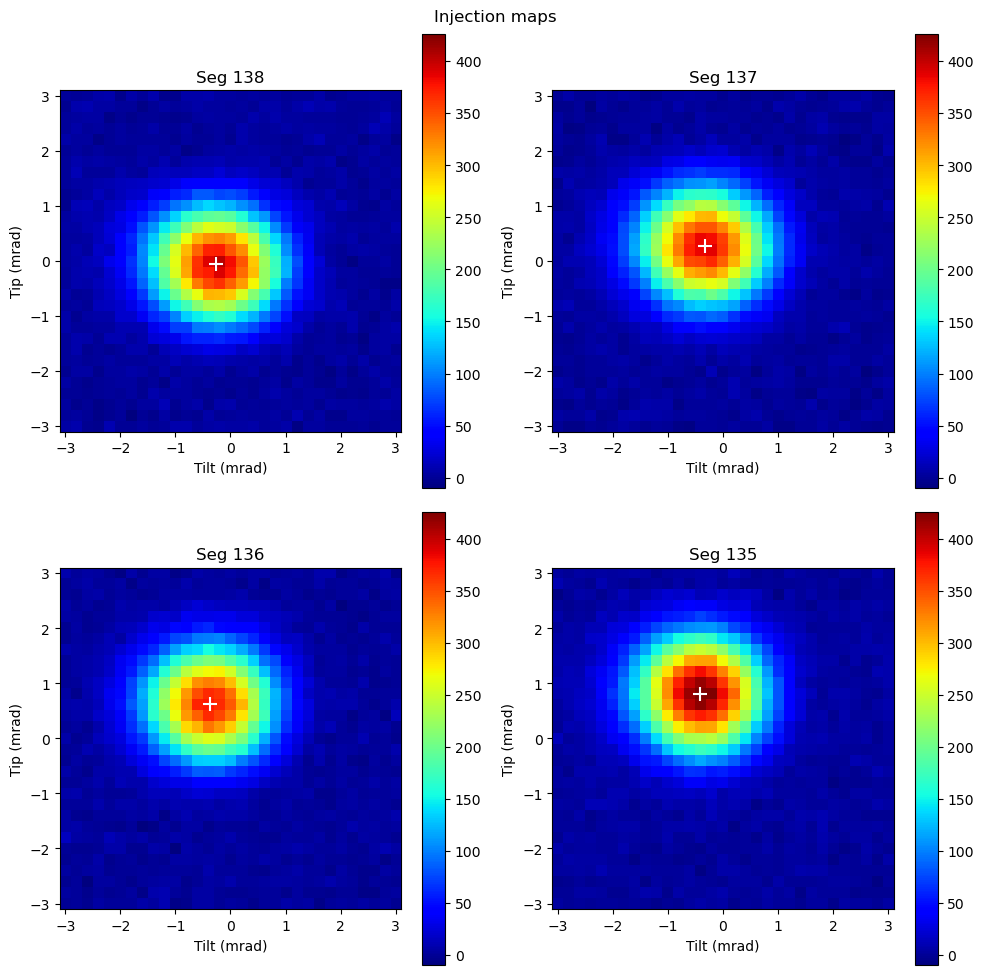

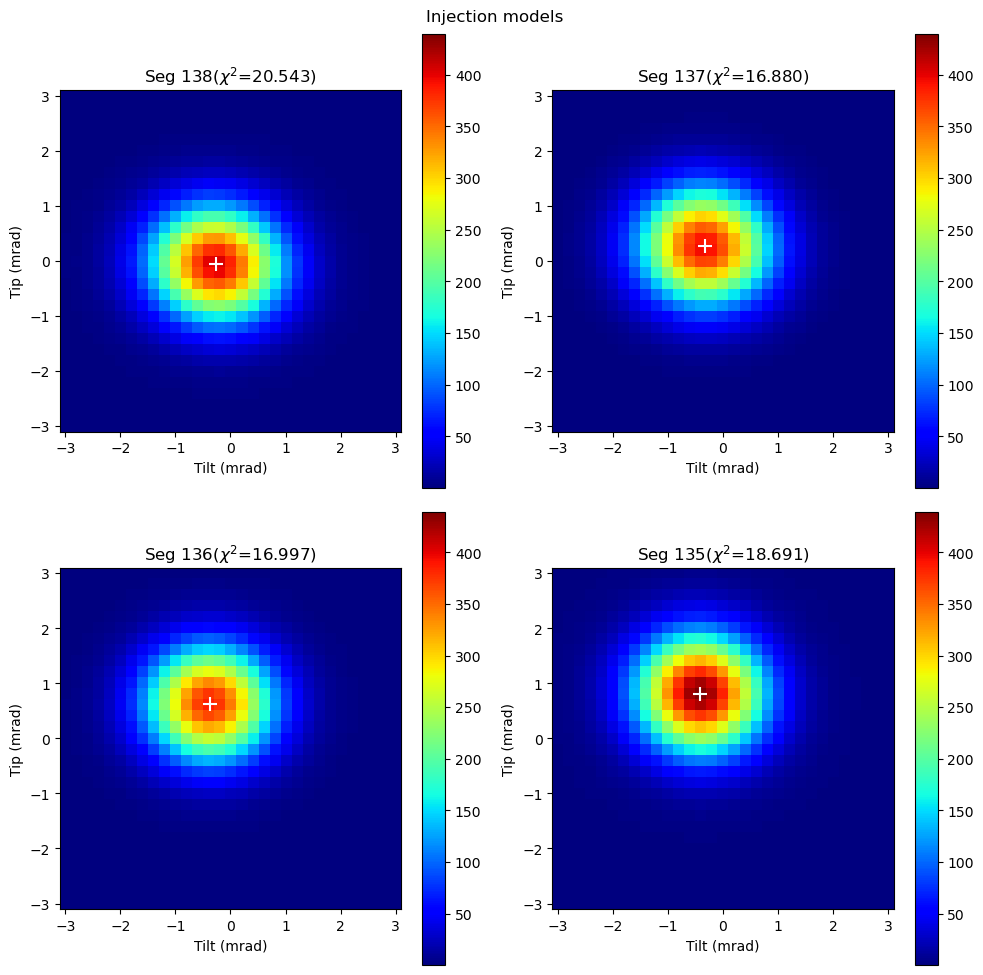

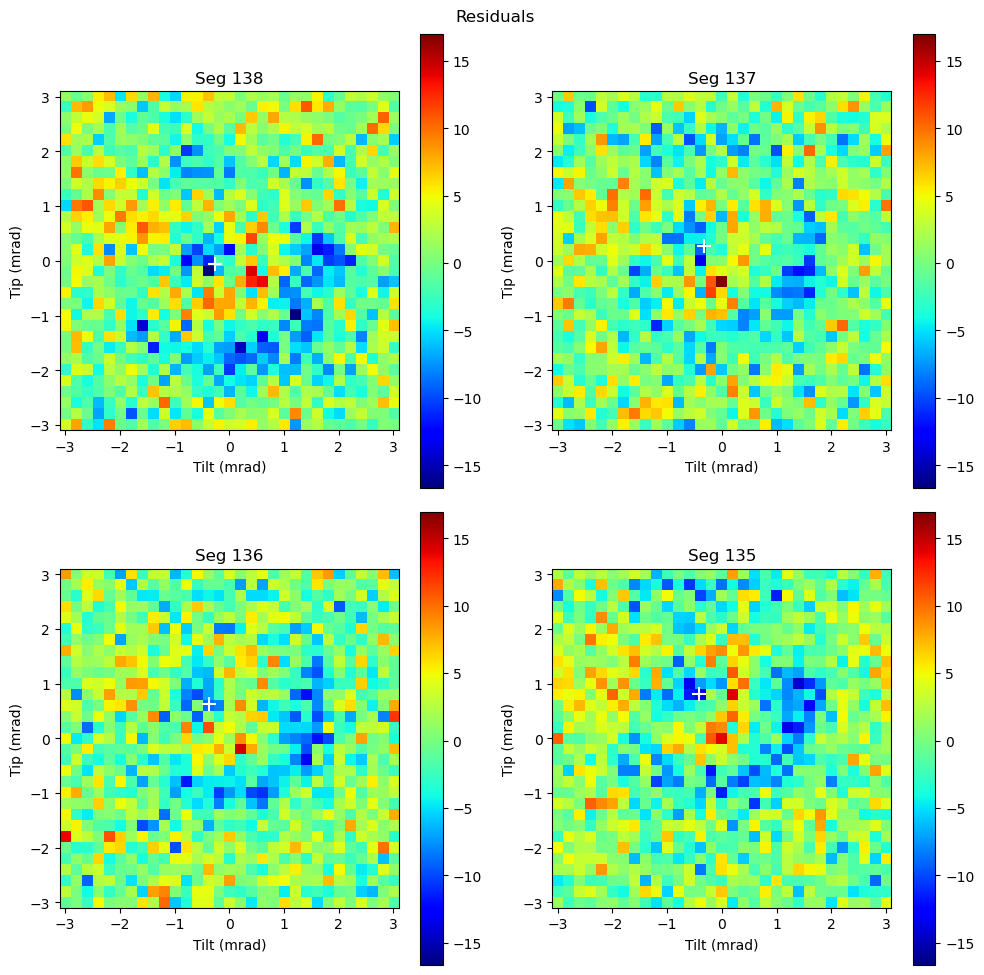

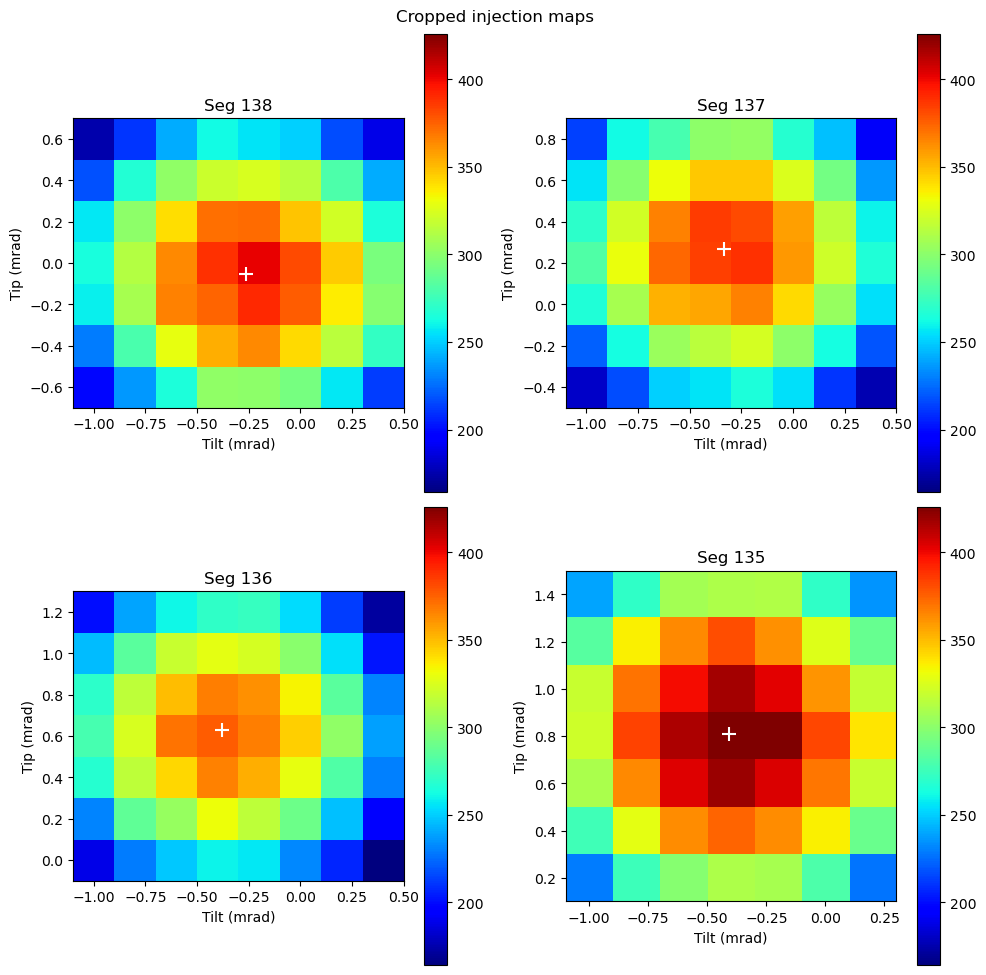

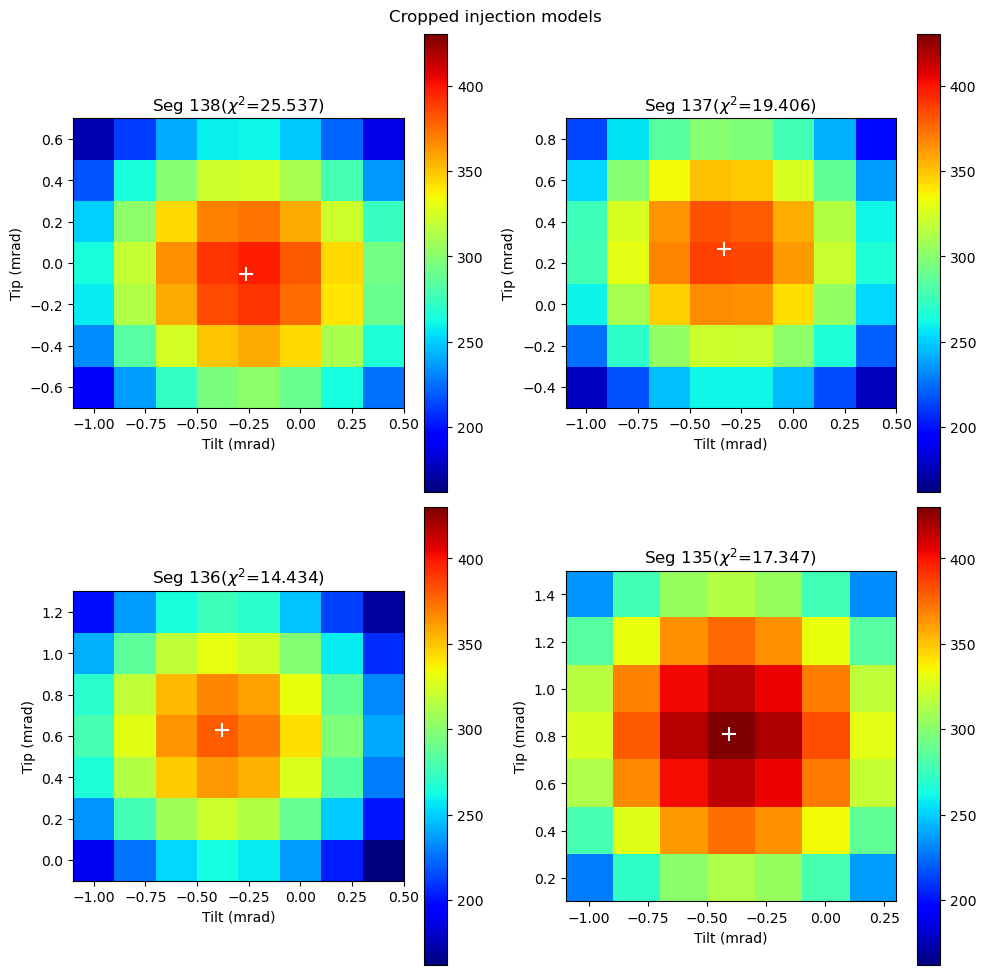

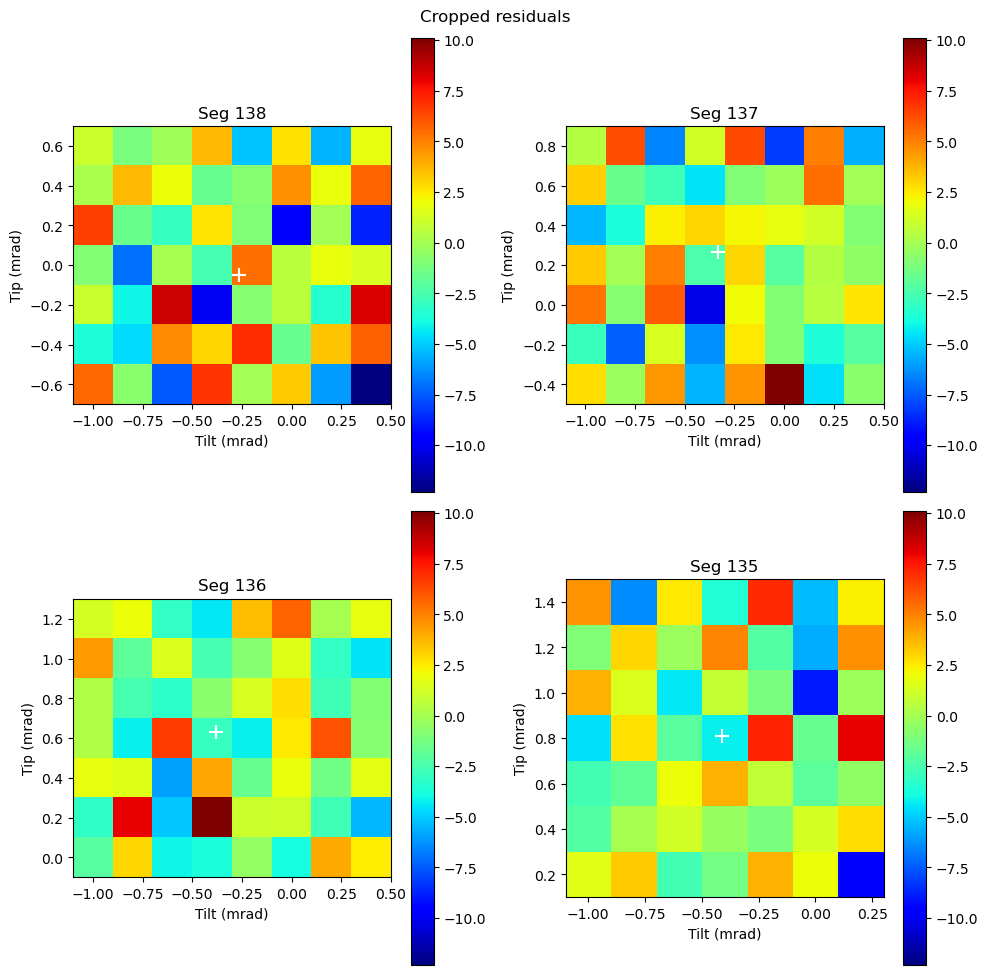

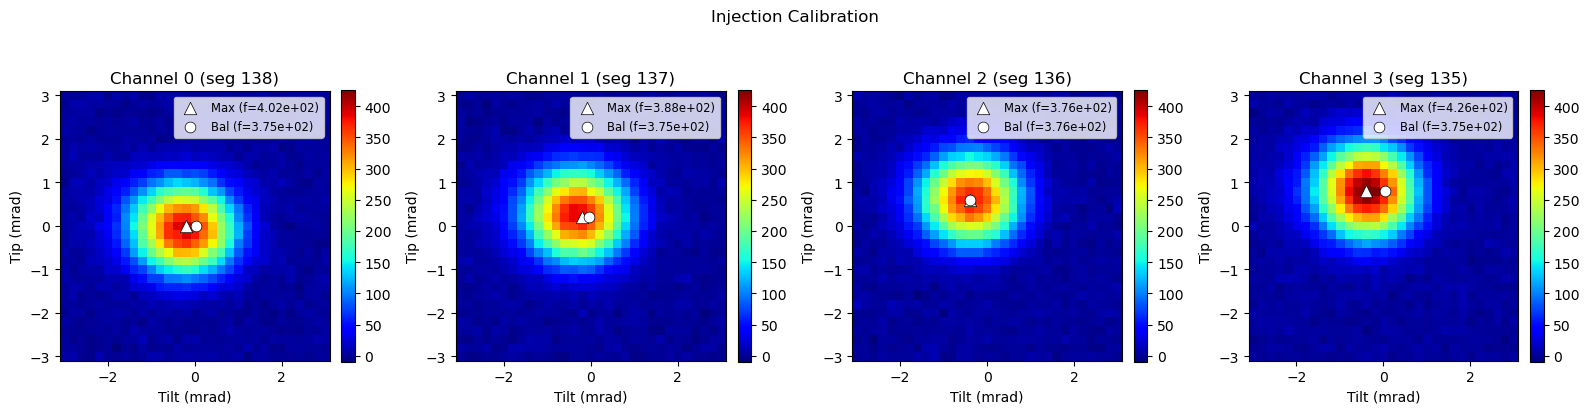

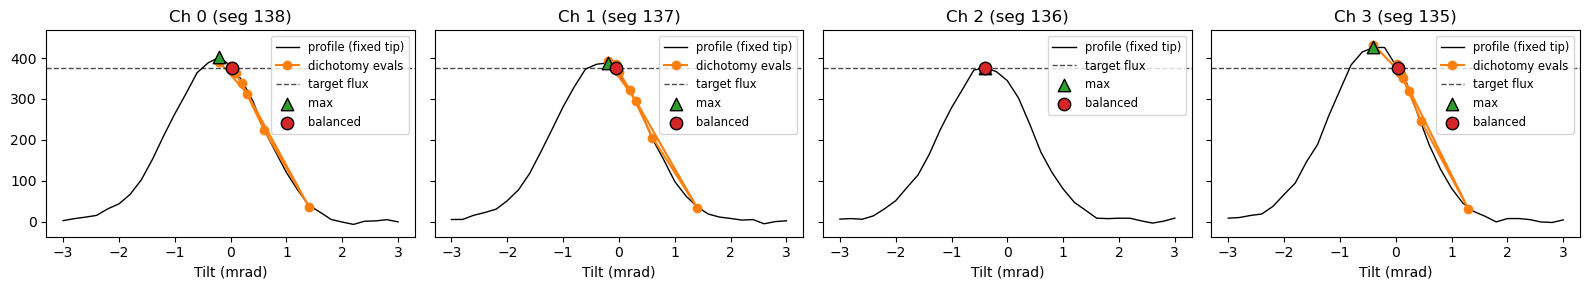

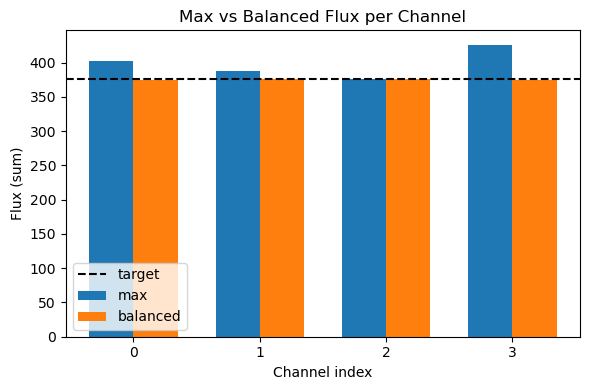

Successfully saved in FITS
Injection ZERO on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection ZERO on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


In [8]:
# Injection calibration
avg_frame = 1
avg_frames_bal = 5
out_inj = inj.calibrate(verbose=True, plot=True, save_path=path, 
                        avg_frames=avg_frame, avg_frames_bal=avg_frames_bal,
                        tilt_tol=0.5e-3)

inj.zero()
bal_list = phobos.Config().get('injection.balanced', None)
max_list = phobos.Config().get('injection.max', None)

filename = 'injection_values_ref_'+datetime.now().strftime("%Y-%m-%dT%H:%M:%S")+'.pkl'
with open(path / filename, 'wb') as f:
    pickle.dump(out_inj, f)


# TOPA calibration

Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
  - Scanning shifter 17...
  ✅ Shifter 17 calibrated: Period=0.5931 W -> Coeff=0.0944 W/rad
  ✅ Shifter 17 calibrated: Period=0.5931 W -> Coeff=0.0944 W/rad
  - Scanning shifter 18...
  - Scanning shifter 18...
  ✅ Shifter 18 calibrated: Period=0.6004 W -> Coeff=0.0956 W/rad
  ✅ Shifter 18 calibrated: Period=0.6004 W -> Coeff=0.0956 W/rad
  - Scanning shifter 19...
  - Scanning shifter 19...
  ✅ Shifter 19 calibrated: Period=0.5967 W -> Coeff=0.0950 W/rad
  ✅ Shifter 19 calibrated: Period=0.5967 W -> Coeff=0.0950 W/rad
  - Scanning shifter 20...
  - Scanning shifter 20...
  ✅ Shifter 20 calibrated: Period=0.6010 W -> Coeff=0.0957 W/rad
  ✅ Shifter 20 calibrated: Period=0.6010 W -> Coeff=0.0957 W/rad


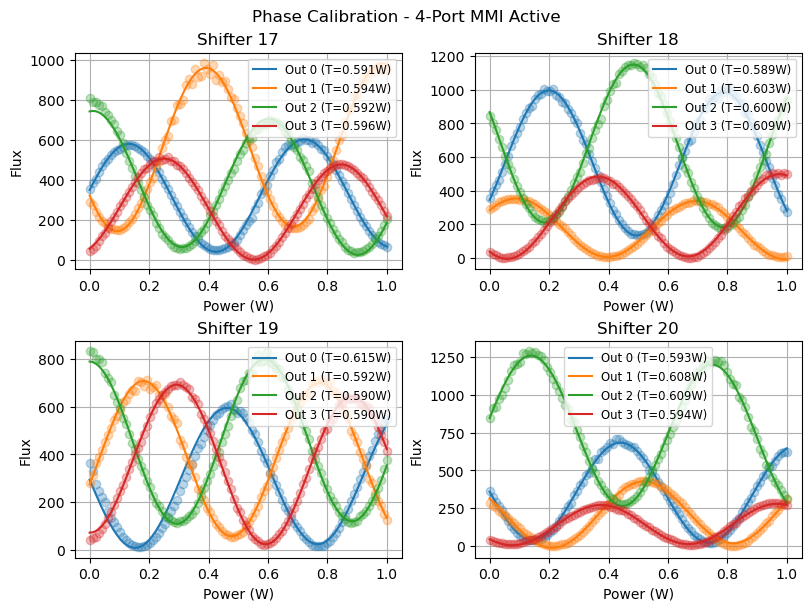

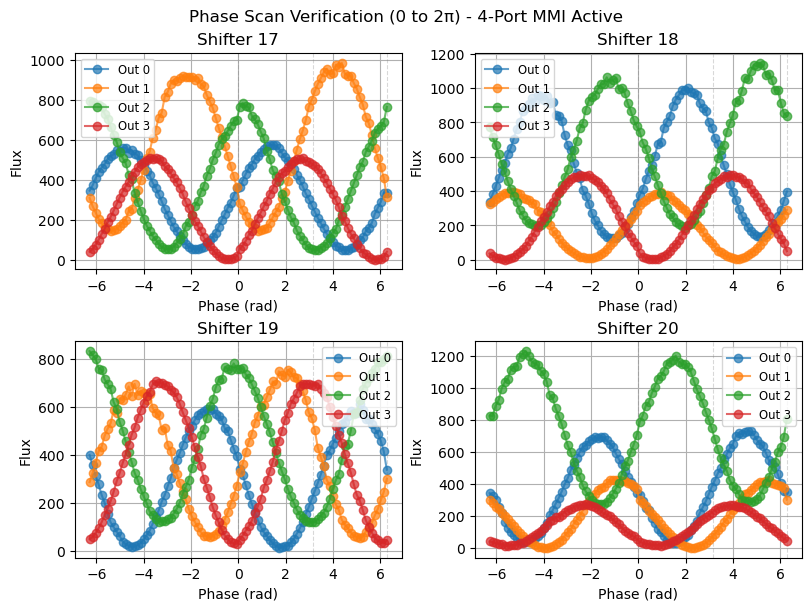

Phase factor
[[17.          0.59311014  0.09439641]
 [18.          0.60037013  0.09555187]
 [19.          0.59671005  0.09496935]
 [20.          0.60100134  0.09565233]]


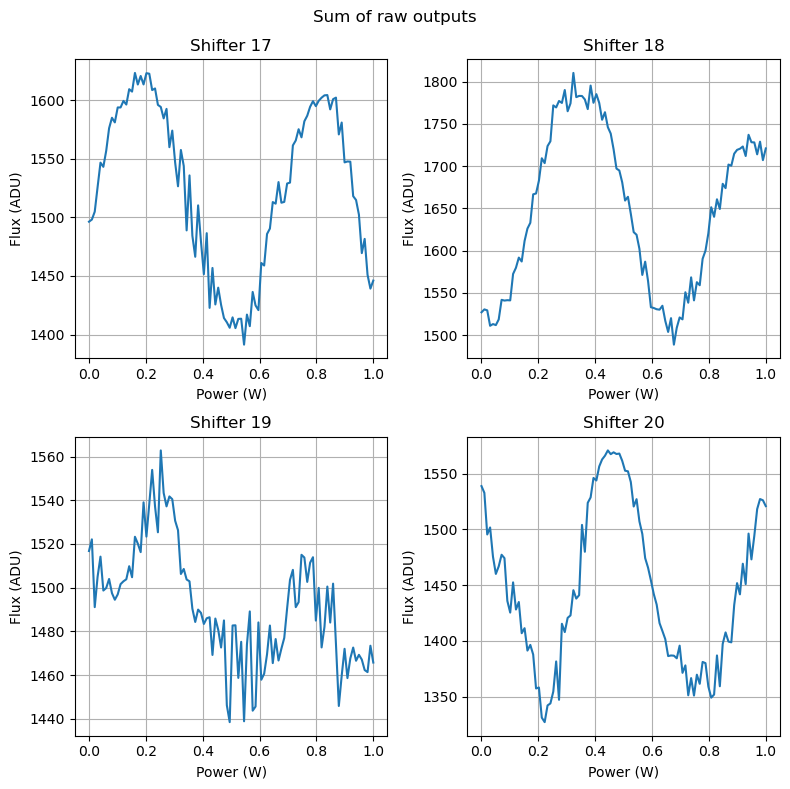

In [10]:
inj.set_balanced()

avg_frames = 5
# TOPAs calibration
# chip_coeffs, chip_scans = chip.phase_calibration2(niter=5, plot=True, verbose=True, avg_frames=avg_frames)

chip_coeffs, chip_scans, chip_power_range = chip.phase_calibration(plot=True, verbose=False)


np.save(path / f"chip_coeffs_seg{seg}.npy", chip_coeffs)
np.save(path / f"chip_scans_seg{seg}.npy", chip_scans)

print('Phase factor')
print(chip_coeffs)

s = chip_scans[:,:,:-1].sum(2)
power_range = np.linspace(0, 1, s.shape[-1])
plt.figure(figsize=(8,8))
plt.suptitle("Sum of raw outputs")
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(power_range, s[i].T)
    plt.grid()
    plt.title(f"Shifter {chip.shifters[i].channel}")
    plt.xlabel("Power (W)")
    plt.ylabel("Flux (ADU)")
plt.tight_layout()

chip.turn_off()

# Conservation of energy?

Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


100%|██████████| 100/100 [00:07<00:00, 12.90it/s]


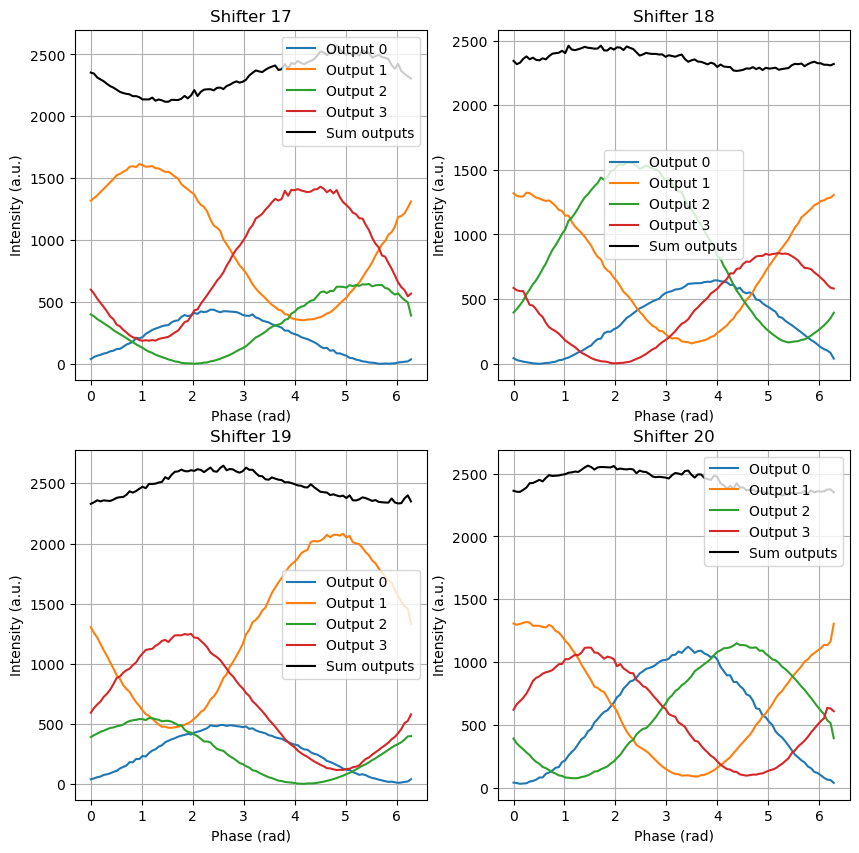

In [14]:
phase_ramp = np.linspace(0, 2 * np.pi, 100)
n_roi = 4
inj.set_balanced()

data_cube = []
for shifter in chip.shifters:
    imgs = []
    for p in tqdm(phase_ramp):
        _ = shifter.set_phase(p)
        img = cam.get_outputs(flux_mode='mean')[:n_roi]
        imgs.append(img)
    data_cube.append(imgs)

data_cube = np.array(data_cube) # Shape (n_shifters, n_phases, n_roi)

fig, axs = plt.subplots(2, 2, figsize=(10,10))
for i, ax in enumerate(axs.flat):
    ax.plot(phase_ramp, data_cube[i])
    ax.plot(phase_ramp, data_cube[i].sum(1), c='k')
    ax.grid(True)
    ax.legend([f'Output {j}' for j in range(n_roi)]+['Sum outputs'])
    ax.set_xlabel("Phase (rad)")
    ax.set_ylabel("Intensity (a.u.)")
    ax.set_title(f"Shifter {chip.shifters[i].channel}")

# Test : 2pi*0.99 shift (to reach max power delivered)

In [15]:
# Set a 2pi shift
n_roi = 4
wait = 0.01
data_cube = []
power_cube = []

chip.turn_off()
time.sleep(1)
for shifter in chip.shifters:
    data_shifters = []
    power_shifters = []
    flx = cam.get_outputs(flux_mode='mean')[:n_roi]
    data_shifters.append(flx)
    power_shifters.append([-0.1, -0.1])
    
    pw = shifter.set_phase(2 * np.pi * 0.99)
    time.sleep(wait)
    flx = cam.get_outputs(flux_mode='mean')[:n_roi]
    data_shifters.append(flx)
    power_shifters.append(pw)

    pw = shifter.set_phase(0.)
    time.sleep(wait)
    flx = cam.get_outputs(flux_mode='mean')[:n_roi]
    data_shifters.append(flx)
    power_shifters.append(pw)

    chip.turn_off()
    time.sleep(wait)
    flx = cam.get_outputs(flux_mode='mean')[:n_roi]
    data_shifters.append(flx)
    power_shifters.append([-0.1, -0.1])

    data_cube.append(data_shifters)
    power_cube.append(power_shifters)

data_cube = np.array(data_cube) # shape (n_shifters, n_frames, n_roi)
power_cube = np.array(power_cube) # shape (n_shifters, n_frames, n_pw)

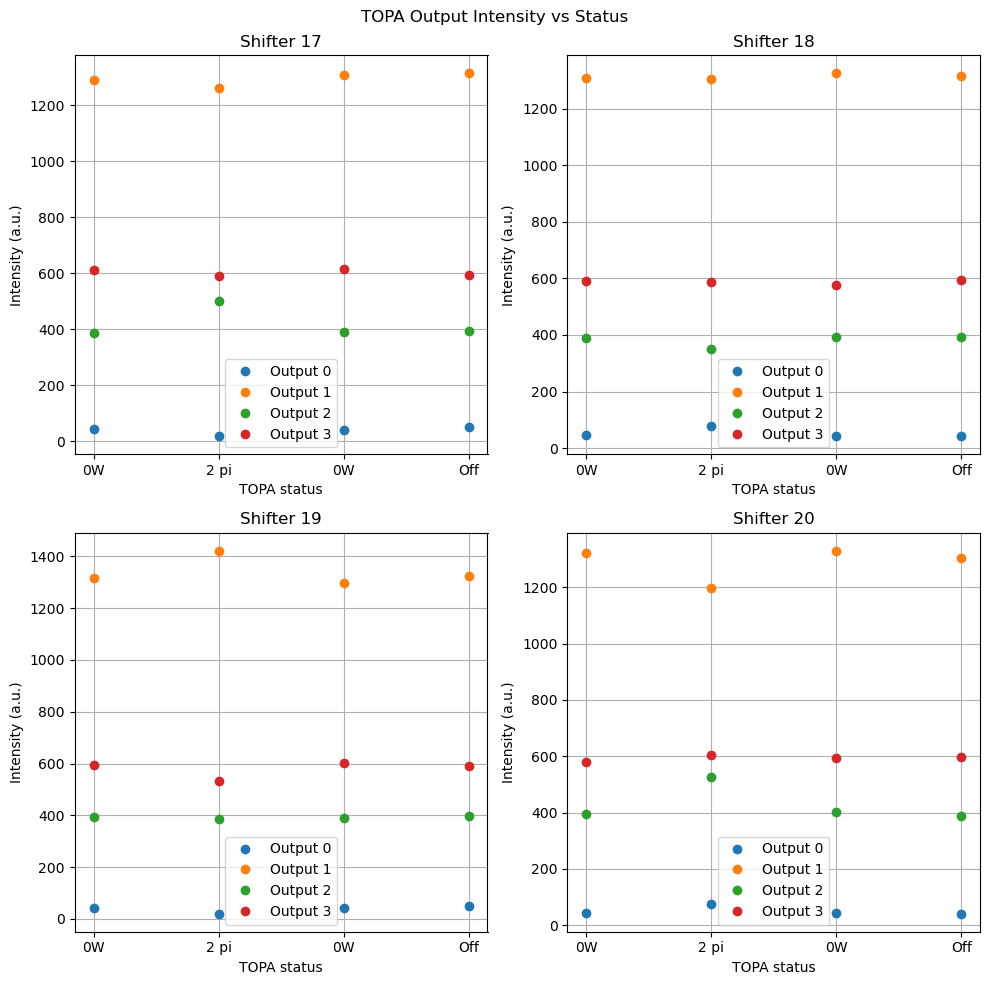

In [16]:
fig, axs = plt.subplots(2, 2, figsize=(10,10))
fig.suptitle("TOPA Output Intensity vs Status")
for i, ax in enumerate(axs.flat):
    ax.plot(data_cube[i], 'o')
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(['0W', '2 pi', '0W', 'Off'])
    ax.grid(True)
    ax.legend([f'Output {j}' for j in range(n_roi)])
    ax.set_ylabel("Intensity (a.u.)")
    ax.set_xlabel("TOPA status")
    ax.set_title(f"Shifter {chip.shifters[i].channel}")
fig.tight_layout()

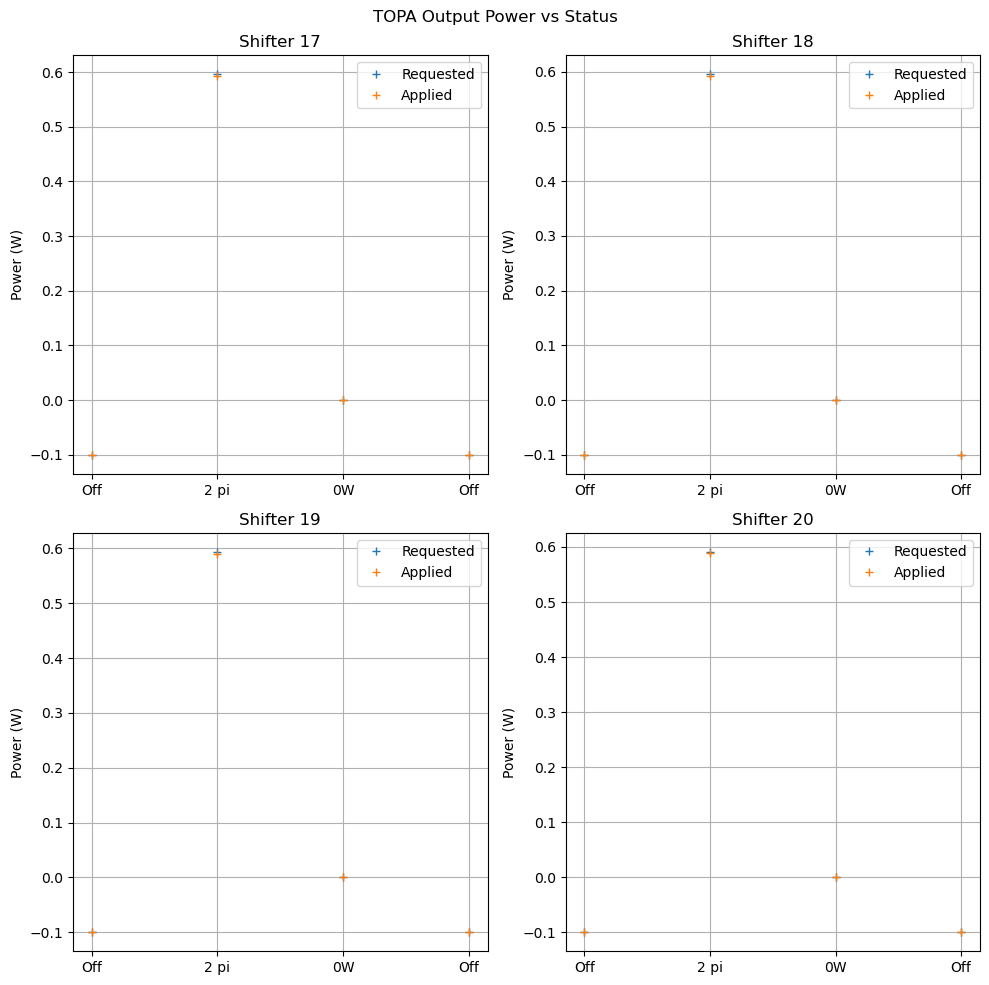

In [17]:
fig, axs = plt.subplots(2, 2, figsize=(10,10))
fig.suptitle("TOPA Output Power vs Status")
for i, ax in enumerate(axs.flat):
    ax.plot(power_cube[i], '+')
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(['Off', '2 pi', '0W', 'Off'])    
    ax.grid(True)
    ax.legend(['Requested', 'Applied'])
    ax.set_ylabel("Power (W)")
    ax.set_title(f"Shifter {chip.shifters[i].channel}")
fig.tight_layout()

# Test : diff power sent
Can't see any relaxation time of the heat despite putting stabilization_time at 0 in bench.yml and no sleep time in the cell below.

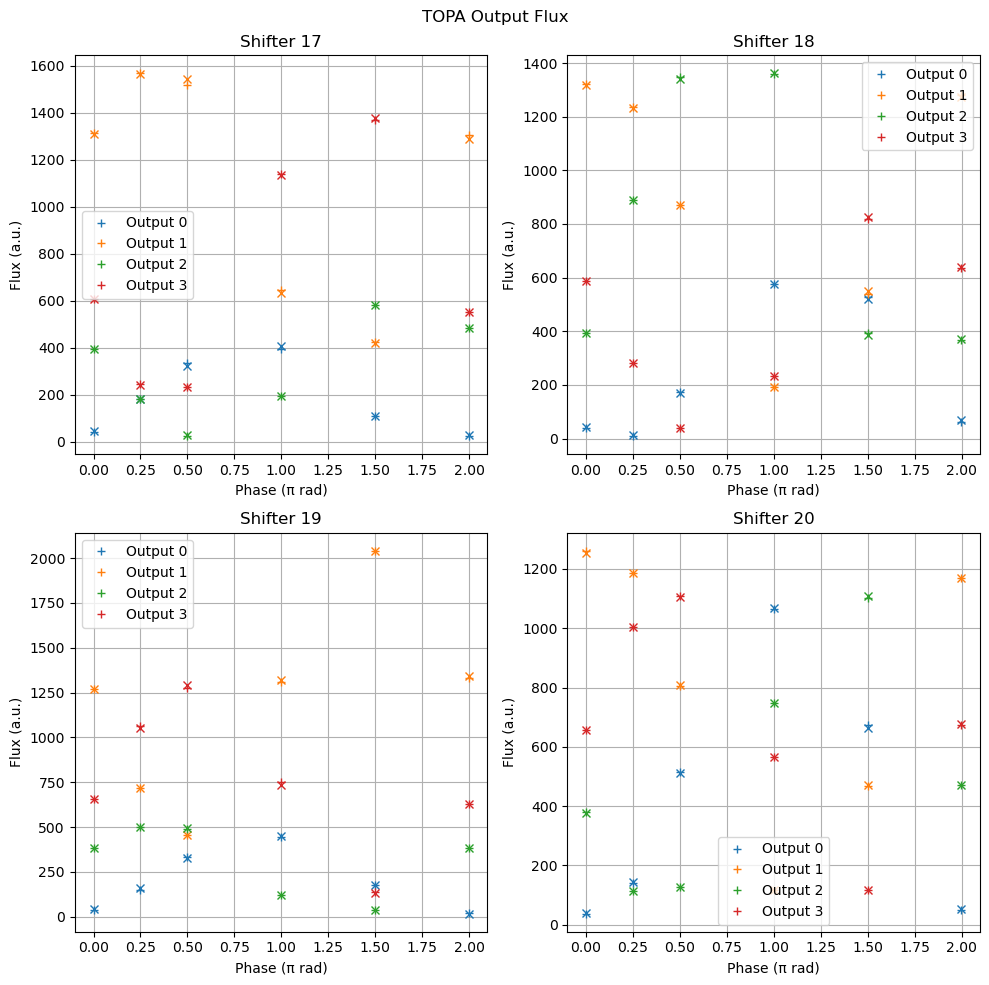

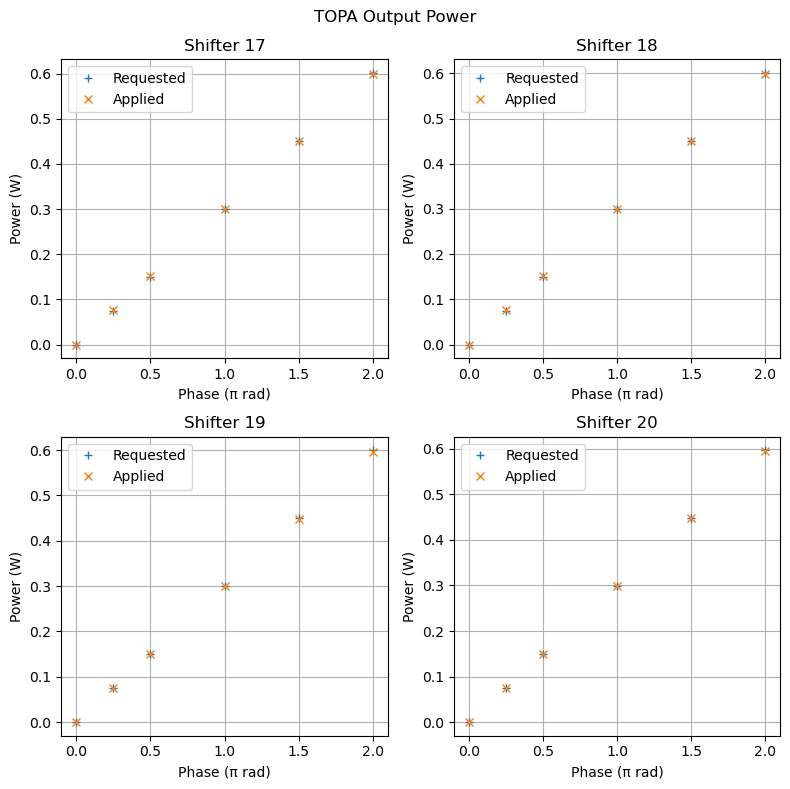

In [18]:
phobos.Config().reload()
phase_change = np.array([0., np.pi / 4, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi*0.999])
wait = 0.
n_output = 4
chip.turn_off()

data = []
data_relax = []
telemetry = []

for shifter in chip.shifters:
    outs = []
    outs_relax = []
    outs_power = []
    for ph in phase_change:
        pw = shifter.set_phase(ph)
        flx = cam.get_outputs(flux_mode='mean')[:n_output]
        outs.append(flx)
        outs_power.append(pw)
        time.sleep(wait)
        flx_relax = cam.get_outputs(flux_mode='mean')[:n_output]
        outs_relax.append(flx_relax)
        shifter.turn_off()
        time.sleep(wait)
    data.append(outs)
    data_relax.append(outs_relax)
    telemetry.append(outs_power)

data = np.array(data) # shape (n_shifters, n_phases, n_output)
data_relax = np.array(data_relax) # shape (n_shifters, n_phases, n_output)
telemetry = np.array(telemetry) # shape (n_shifters, n_phases, 2)

fig, axs = plt.subplots(2, 2, figsize=(10,10))
fig.suptitle("TOPA Output Flux")
for i, ax in enumerate(axs.flat):
    for k in range(data.shape[-1]):
        line, = ax.plot(phase_change/np.pi, data[i,:,k], '+', label=f'Output {k}')
        ax.plot(phase_change/np.pi, data_relax[i,:,k], 'x', c=line.get_color())
    ax.grid(True)
    ax.legend(ncols=1)
    ax.set_ylabel("Flux (a.u.)")
    ax.set_xlabel("Phase (π rad)")
    ax.set_title(f"Shifter {chip.shifters[i].channel}")
fig.tight_layout()

fig, axs = plt.subplots(2, 2, figsize=(8,8))
fig.suptitle("TOPA Output Power")
for i, ax in enumerate(axs.flat):
    ax.plot(phase_change/np.pi, telemetry[i,:,0], '+', label=f'Requested')
    ax.plot(phase_change/np.pi, telemetry[i,:,1], 'x', label=f'Applied')
    ax.grid(True)
    ax.legend()
    ax.set_ylabel("Power (W)")
    ax.set_xlabel("Phase (π rad)")
    ax.set_title(f"Shifter {chip.shifters[i].channel}")
fig.tight_layout()

# Single beam and phase shifter crosstalk

Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0] (segments [138])
Scanning shifter: 17


100%|██████████| 101/101 [00:08<00:00, 12.44it/s]


Scanning shifter: 18


100%|██████████| 101/101 [00:08<00:00, 12.51it/s]


Scanning shifter: 19


...

Scanning shifter: 19


100%|██████████| 101/101 [00:08<00:00, 12.51it/s]


Scanning shifter: 20


100%|██████████| 101/101 [00:08<00:00, 12.51it/s]


(4, 4, 101, 4)
Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


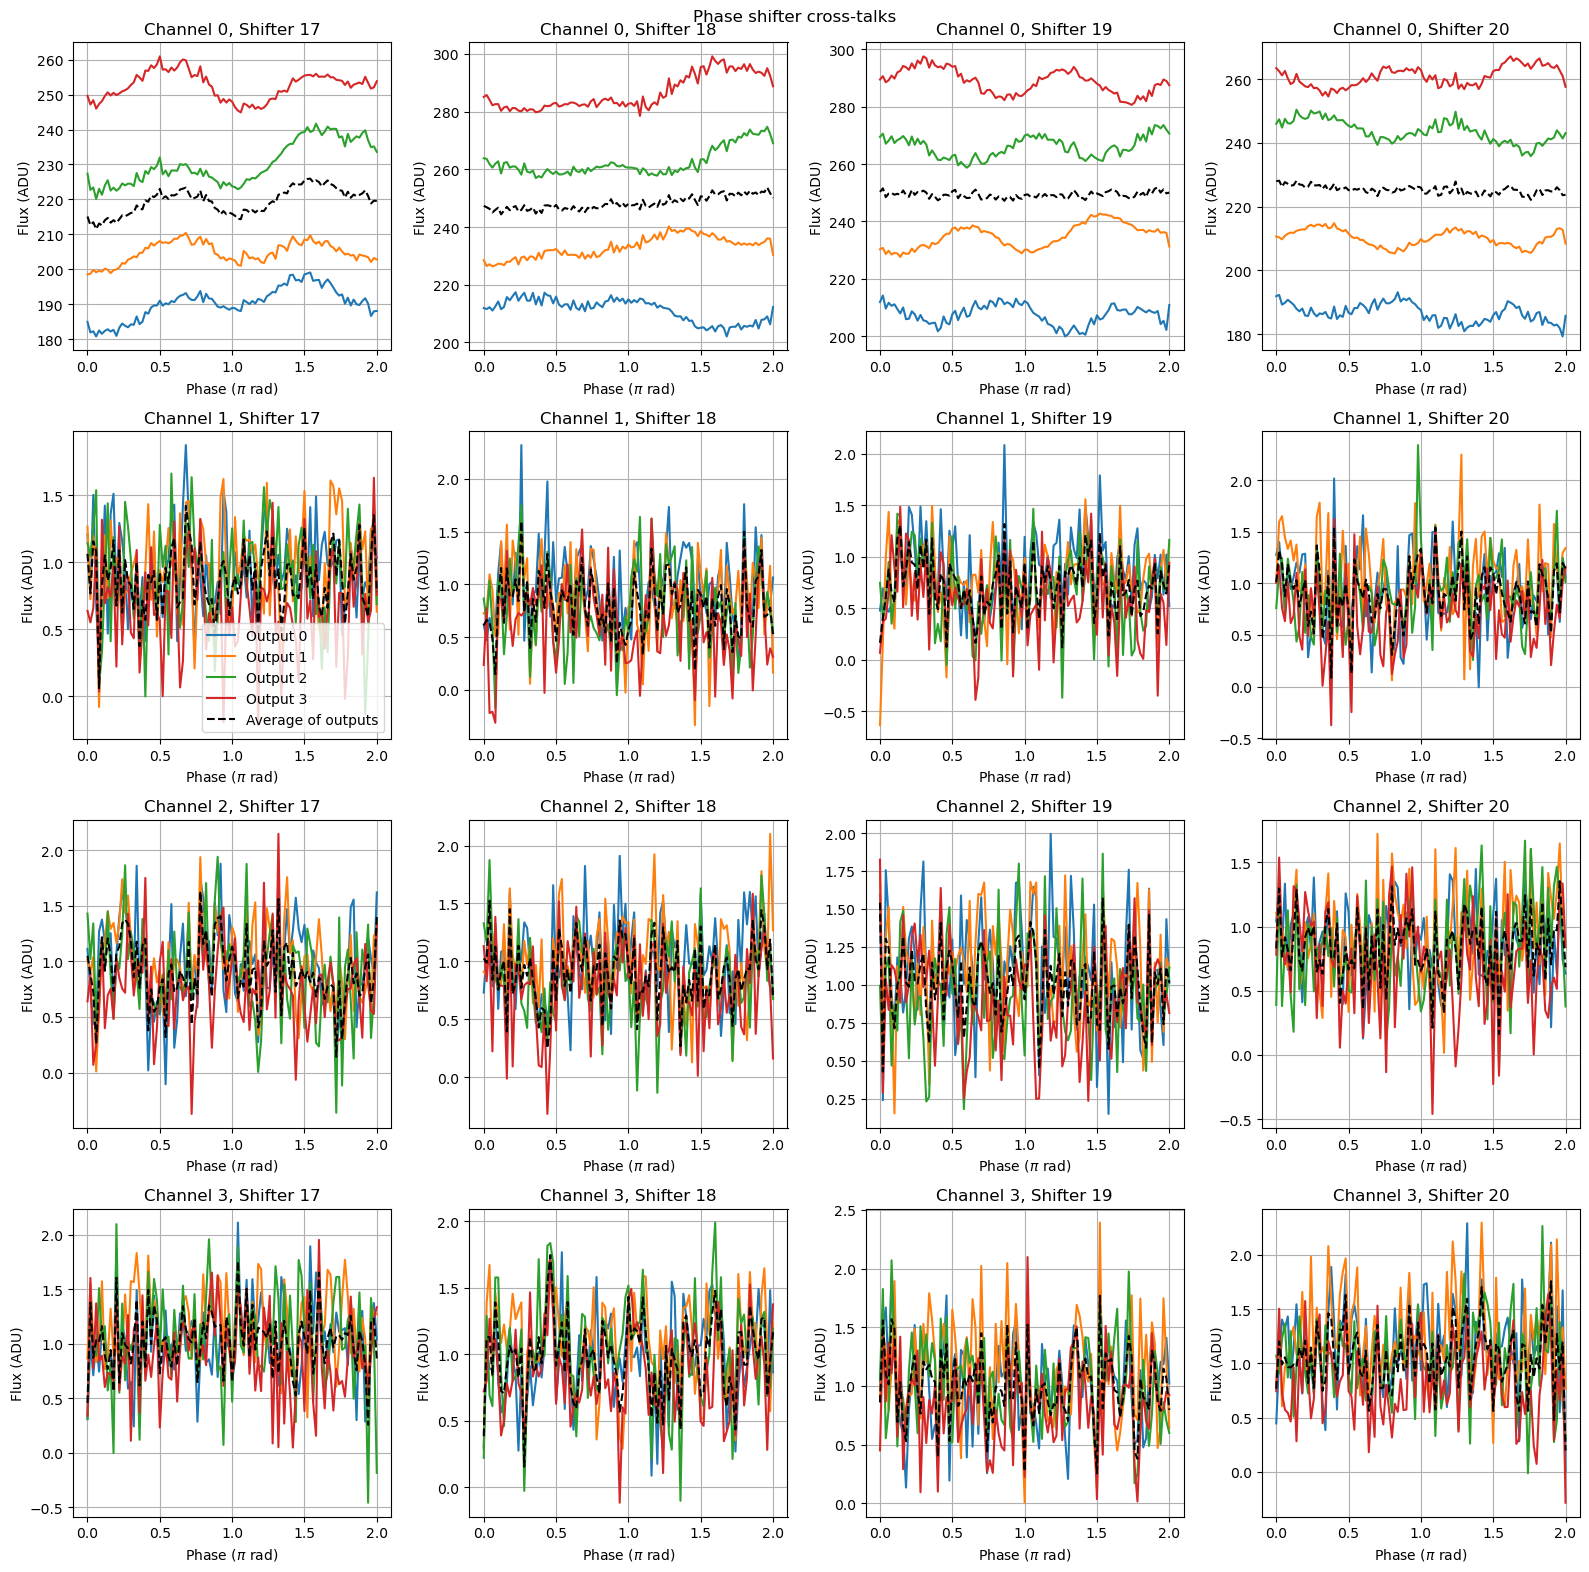

In [8]:
channels = [0, 1, 2, 3]
phase_ramp = np.linspace(0, 2*np.pi, 101)
n_outputs = 4
avg_frames = 5
niter = 5
chip.turn_off()

data = []
for ch in channels:
    inj.off()
    inj.set_balanced(ch)
    flx_shifter = []
    for shifter in chip.shifters:
        print('Scanning shifter:', shifter.channel)
        iter_list = []
        for it in range(niter):
            flux = []
            for phase in tqdm(phase_ramp):
                shifter.set_phase(phase)
                flx = cam.get_outputs(flux_mode='mean', stack=avg_frames)[:n_outputs]
                flux.append(flx)
            iter_list.append(flux)
        iter_list = np.array(iter_list)
        iter_list = iter_list.mean(0)
        flx_shifter.append(iter_list)
        shifter.turn_off()
        time.sleep(1.)
    data.append(flx_shifter)

data = np.array(data) # shape (n_channels, n_shifters, n_phases, n_outputs)
print(data.shape)
np.savez(path / f'phase_shifter_seg{seg}_crosstalks', data=data, phase_ramp=phase_ramp)

inj.set_balanced()
chip.turn_off()

fig, axs = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle('Phase shifter cross-talks')
for ch in channels:
    for shifter_idx, shifter in enumerate(chip.shifters):
        axs[ch, shifter_idx].plot(phase_ramp/np.pi, data[ch, shifter_idx])
        axs[ch, shifter_idx].plot(phase_ramp/np.pi, data[ch, shifter_idx].mean(-1), '--', c='k')
        axs[ch, shifter_idx].set_title(f'Channel {ch}, Shifter {shifter.channel}')
        axs[ch, shifter_idx].set_xlabel(r'Phase ($\pi$ rad)')
        axs[ch, shifter_idx].set_ylabel('Flux (ADU)')
        axs[ch, shifter_idx].grid(True)
        if ch == 1 and shifter_idx == 0:
            axs[ch, shifter_idx].legend([f'Output {i}' for i in range(n_outputs)]+['Average of outputs'], loc='best')
fig.tight_layout()
fig.savefig(path / f'phase_shifter_seg{seg}_crosstalks.png', dpi=150)



# Incoherent scan

Segment: 138
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection MAX on channels [0] (segments [138])
Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


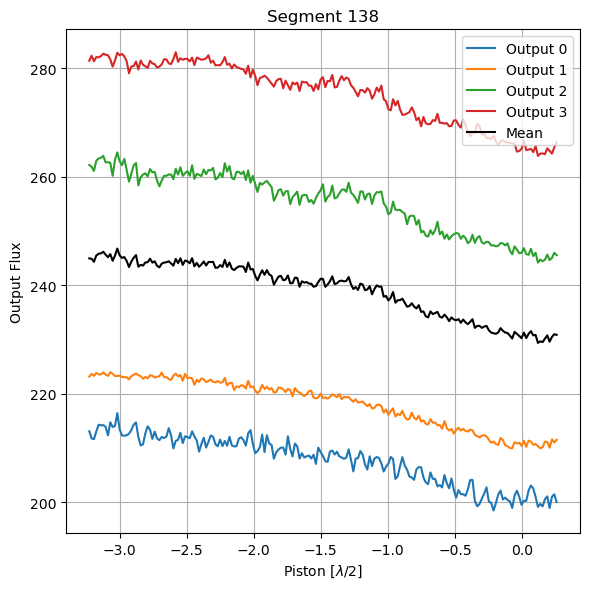

In [9]:
n_roi = 4
avg_frames = 5
piston_range = np.linspace(-2500, 200, 201)  # [nm]
print('Segment:', seg)
niter = 5

res_single_scan = {}
fig, axs = plt.subplots(1, 1, figsize=(6, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

total_flux = []
chip.turn_off()
inj.off()
inj.set_max(beam)

ref_tip = dm[inj_seg[beam]].get_tip()
ref_tilt = dm[inj_seg[beam]].get_tilt()

outs = np.empty((niter, len(piston_range), n_roi))
for i in range(niter):
    outs_iter = np.empty((len(piston_range), n_roi))
    for p, opd in enumerate(piston_range):
        dm[inj_seg[beam]].set_ptt(opd, ref_tip, ref_tilt)
        time.sleep(0.005)
        outs_iter[p] = cam.get_outputs(flux_mode='mean', stack=avg_frames)[:n_roi]
    outs[i] = outs_iter
outs = outs.mean(0)

res_single_scan[inj_seg[beam]] = outs.copy()
total_flux.append(outs[:].sum(axis=1))

for o in range(n_roi):
    axs.plot(piston_range / (lam/2), outs[:, o], color=colors[o], linestyle='-', label=f'Output {o}')
axs.plot(piston_range / (lam/2), outs.mean(1), color='k', linestyle='-', label=f'Mean')
axs.set_title(f'Segment {inj_seg[beam]}')
axs.set_xlabel(r'Piston [$\lambda/2$]')
axs.set_ylabel('Output Flux')
axs.legend()
axs.grid()


fig.tight_layout()
fig.savefig(path / f'singlebeam_seg{seg}_scan_incoherent.png')

np.savez(path / f'singlebeam_seg{seg}_scan_incoherent.npz', data=outs, piston_range=piston_range)

inj.set_balanced()


# TOPA stability
## 1 phase shifter

In [ ]:
# Injection calibration
avg_frame = 1
avg_frames_bal = 5
out_inj = inj.calibrate(verbose=True, plot=True, save_path=path, 
                        avg_frames=avg_frame, avg_frames_bal=avg_frames_bal,
                        tilt_tol=0.5e-3)

inj.zero()

filename = 'injection_values_before1ps_'+datetime.now().strftime("%Y-%m-%dT%H:%M:%S")+'.pkl'
with open(path / filename, 'wb') as f:
    pickle.dump(out_inj, f)


phobos.Config().set('injection.balanced', bal_list)
phobos.Config().set('injection.max', max_list)
phobos.Config().save_to_file()

# TOPA

nb_frames = 5

# Parameters for the stability test
dt = 0.25 # Image acquisition period in min
T_total = 15 # Total duration in min

nb_points = int(T_total // dt)

power_on_time = 5.0   # Time when the phase shifter turns ON (min)
power_off_time = 10.0  # Time when the phase shifter turns OFF (min)
# shifter_idx = 0        # Index of the shifter to test (e.g., 0 for the first one)

dt *= 60.
T_total *= 60.
power_on_time *= 60.
power_off_time *= 60.

temp_probe = open_port()

phobos.Config().set('injection.balanced', bal_list)
phobos.Config().set('injection.max', max_list)
phobos.Config().save_to_file()

for shifter_idx in range(4):
    # The target power is the mean power over a period as obtained from calibration
    target_power = chip_coeffs[shifter_idx, 1] / 2.

    shifter = chip.shifters[shifter_idx]

    # Setup the bench
    chip.turn_off()
    inj.set_balanced()
    time.sleep(1.0)

    print(f"Starting stability test on Shifter {shifter.channel} for {T_total}s...")
    print(f"Target power: {target_power:.3f} W")

    datacube = []
    start_time = time.time()

    is_on = False
    current_power = 0.0

    # Loop for the duration of the experiment
    next_acq_time = start_time + dt
    with tqdm(total=int(T_total/dt)) as pbar:
        while True:
            current_time = time.time()
            elapsed = current_time - start_time
            
            if elapsed >= T_total:
                break
                
            # Phase shifter activation logic
            if power_on_time <= elapsed < power_off_time:
                if not is_on:
                    shifter.set_power(target_power)
                    is_on = True
            else:
                if is_on:
                    shifter.turn_off()
                    is_on = False
            
            current_power = shifter.get_power()   
                
            # Data acquisition
            actual_time = time.time()
            actual_elapsed = actual_time - start_time
            fluxes = cam.get_outputs(flux_mode='mean', stack=nb_frames)
            temperature = float(read_temp(temp_probe))

            # Save timestamp, applied power, and the output fluxes
            datacube.append([actual_elapsed, temperature, float(target_power), current_power, *fluxes])

            # Wait until the next acquisition tick to keep the dt period
            now = time.time()
            if now < next_acq_time:
                time.sleep(next_acq_time - now)

            # Schedule next acquisition
            next_acq_time += dt
            pbar.update(1)

    # Cleanup
    chip.turn_off()

    # Convert and save
    datacube = np.array(datacube)
    filename = 'topa_stability_shifter%s_%.1fW_%s.npy'%(shifter.channel, target_power, datetime.now().strftime("%Y-%m-%dT%H:%M:%S"))
    np.save(path / filename, datacube)
    print(f"✅ Data saved to {path / filename}")
    print('')

temp_probe.close()

# Injection calibration
avg_frame = 1
avg_frames_bal = 5
out_inj = inj.calibrate(verbose=True, plot=False, save_path=path, 
                        avg_frames=avg_frame, avg_frames_bal=avg_frames_bal,
                        tilt_tol=0.5e-3)

inj.zero()

filename = 'injection_values_after1ps_'+datetime.now().strftime("%Y-%m-%dT%H:%M:%S")+'.pkl'
with open(path / filename, 'wb') as f:
    pickle.dump(out_inj, f)


phobos.Config().set('injection.balanced', bal_list)
phobos.Config().set('injection.max', max_list)
phobos.Config().save_to_file()

Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Starting stability test on Shifter 17 for 900.0s...
Target power: 0.598 W


100%|██████████| 60/60 [14:59<00:00, 15.00s/it]


✅ Data saved to /mnt/disk1/archive/2026-04-17_fdfc996/3_topa_power/topa_stability_shifter17_0.6W.npy

Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Starting stability test on Shifter 18 for 900.0s...
Target power: 0.603 W


100%|██████████| 60/60 [14:59<00:00, 15.00s/it]


✅ Data saved to /mnt/disk1/archive/2026-04-17_fdfc996/3_topa_power/topa_stability_shifter18_0.6W.npy

Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Starting stability test on Shifter 19 for 900.0s...
Target power: 0.596 W


100%|██████████| 60/60 [14:59<00:00, 15.00s/it]


✅ Data saved to /mnt/disk1/archive/2026-04-17_fdfc996/3_topa_power/topa_stability_shifter19_0.6W.npy

Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Starting stability test on Shifter 20 for 900.0s...
Target power: 0.600 W


100%|██████████| 60/60 [14:59<00:00, 15.00s/it]

✅ Data saved to /mnt/disk1/archive/2026-04-17_fdfc996/3_topa_power/topa_stability_shifter20_0.6W.npy



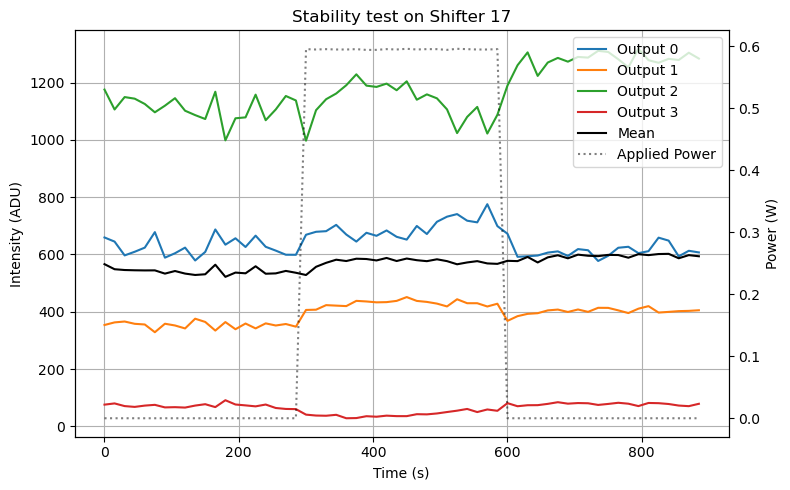

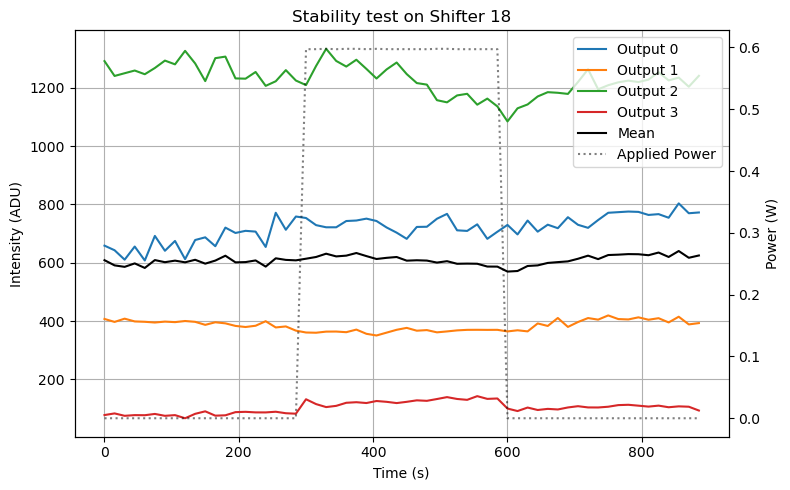

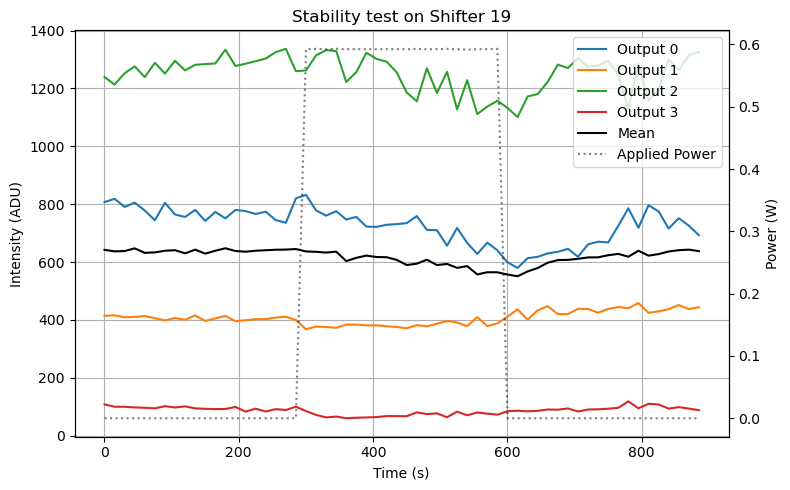

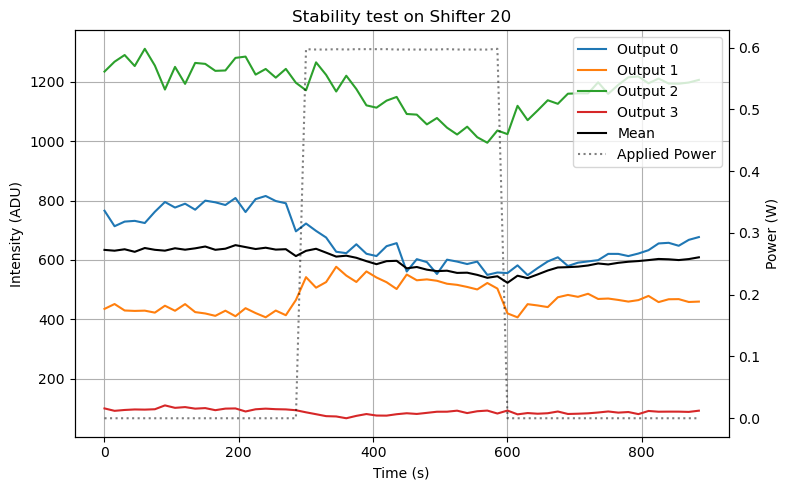

In [29]:
# Plot the result to verify
for shifter_idx in range(4):
    try:
        shifter = chip.shifters[shifter_idx]
        filename = 'topa_stability_shifter%s_%.1fW.npy'%(shifter.channel, target_power)
        datacube = np.load(path / filename)
        fluxes = datacube[:, -5:-1] - datacube[:, -1][:,None]

        fig, ax1 = plt.subplots(figsize=(8, 5))
        plt.title(f"Stability test on Shifter {shifter.channel}")
        plot_cols = datacube[:, 3:-1].shape[1]
        [ax1.plot(datacube[:, 0], fluxes[:,i], label=f'Output {i}') for i in range(plot_cols-1)]
        ax1.plot(datacube[:, 0], fluxes.mean(axis=1), label='Mean', color='k', linestyle='-')
        ax1.set_ylabel("Intensity (ADU)")
        ax1.set_xlabel("Time (s)")
        ax1.grid(True)

        # Plot the requested and applied power on a secondary axis
        ax2 = ax1.twinx()
        # ax2.plot(datacube[:, 0], datacube[:, 1], '--', color='k', alpha=0.5, label='Requested Power')
        ax2.plot(datacube[:, 0], datacube[:, 3], ':', color='k', alpha=0.5, label='Applied Power')
        ax2.set_ylabel("Power (W)")

        # Combine legends from both axes
        lines_1, labels_1 = ax1.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best')

        fig.tight_layout()
        figname = f'topa_stability_shifter{shifter.channel}_{target_power:.1f}W.png'
        fig.savefig(path / figname, dpi=150)
    except FileNotFoundError:
        pass

## 4 phase shifters

Scanning injection maps:   0%|          | 0/4 [00:00<?, ?it/s]

  Channel 0 (segment 138): scanning…
Injection OFF on channels [1, 2, 3] (segments [137, 136, 135])


Scanning injection maps:  25%|██▌       | 1/4 [00:14<00:43, 14.46s/it]

Injection OFF on channels [0] (segments [138])
  Channel 1 (segment 137): scanning…
Injection OFF on channels [0, 2, 3] (segments [138, 136, 135])


Scanning injection maps:  50%|█████     | 2/4 [00:31<00:31, 16.00s/it]

...

Scanning injection maps:  75%|███████▌  | 3/4 [00:47<00:15, 16.00s/it]

Injection OFF on channels [2] (segments [136])
  Channel 3 (segment 135): scanning…
Injection OFF on channels [0, 1, 2] (segments [138, 137, 136])


Scanning injection maps: 100%|██████████| 4/4 [01:07<00:00, 16.79s/it]

Injection OFF on channels [3] (segments [135])
Injection FLAT on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])

── Find gross TT for max injection and spread ──
Injection spread of seg=138: (tip, tilt) = (0.69604,0.79450) mrad
Injection spread of seg=137: (tip, tilt) = (0.71379,0.79167) mrad
Injection spread of seg=136: (tip, tilt) = (0.70251,0.76850) mrad
Injection spread of seg=135: (tip, tilt) = (0.71244,0.77858) mrad

── Find precise TT for max injection ──
Injection max of seg=138: (tip, tilt) = (-0.00499,-0.15009) mrad; flux = 782.4
Injection max of seg=137: (tip, tilt) = (0.29860,-0.22979) mrad; flux = 711
Injection max of seg=136: (tip, tilt) = (0.69433,-0.28926) mrad; flux = 671.9
Injection max of seg=135: (tip, tilt) = (0.87238,-0.32128) mrad; flux = 897.7
✅ Injection calibration saved to config (injection.max)



── Finding maximum injection points ──

── Balancing injection fluxes ──
  Weakest channel: 2 (seg 136), target flux = 692.2
  Dichotomy on channel 0 (seg 138)…
Injection OFF on channels [1, 2, 3] (segments [137, 136, 135])
    → balanced tilt = 0.2049 mrad, flux = 685.3 (target 692.2), iterations = 13
  Dichotomy on channel 1 (seg 137)…
Injection OFF on channels [0, 2, 3] (segments [138, 136, 135])
    → balanced tilt = 0.2049 mrad, flux = 685.3 (target 692.2), iterations = 13
  Dichotomy on channel 1 (seg 137)…
Injection OFF on channels [0, 2, 3] (segments [138, 136, 135])
    → balanced tilt = -0.0990 mrad, flux = 687.9 (target 692.2), iterations = 13
  Dichotomy on channel 3 (seg 135)…
Injection OFF on channels [0, 1, 2] (segments [138, 137, 136])
    → balanced tilt = -0.0990 mrad, flux = 687.9 (target 692.2), iterations = 13
  Dichotomy on channel 3 (seg 135)…
Injection OFF on channels [0, 1, 2] (segments [138, 137, 136])
    → balanced tilt = 0.1323 mrad, flux = 688.9 (target 6

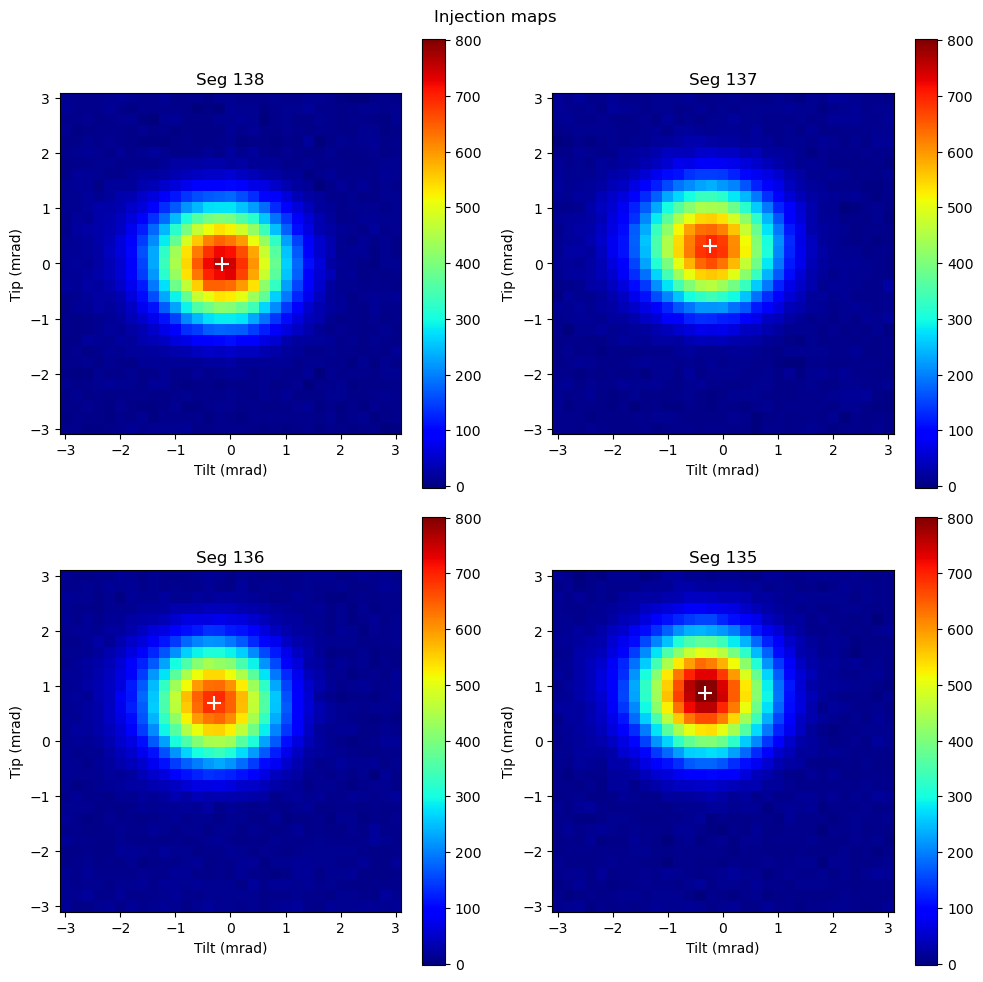

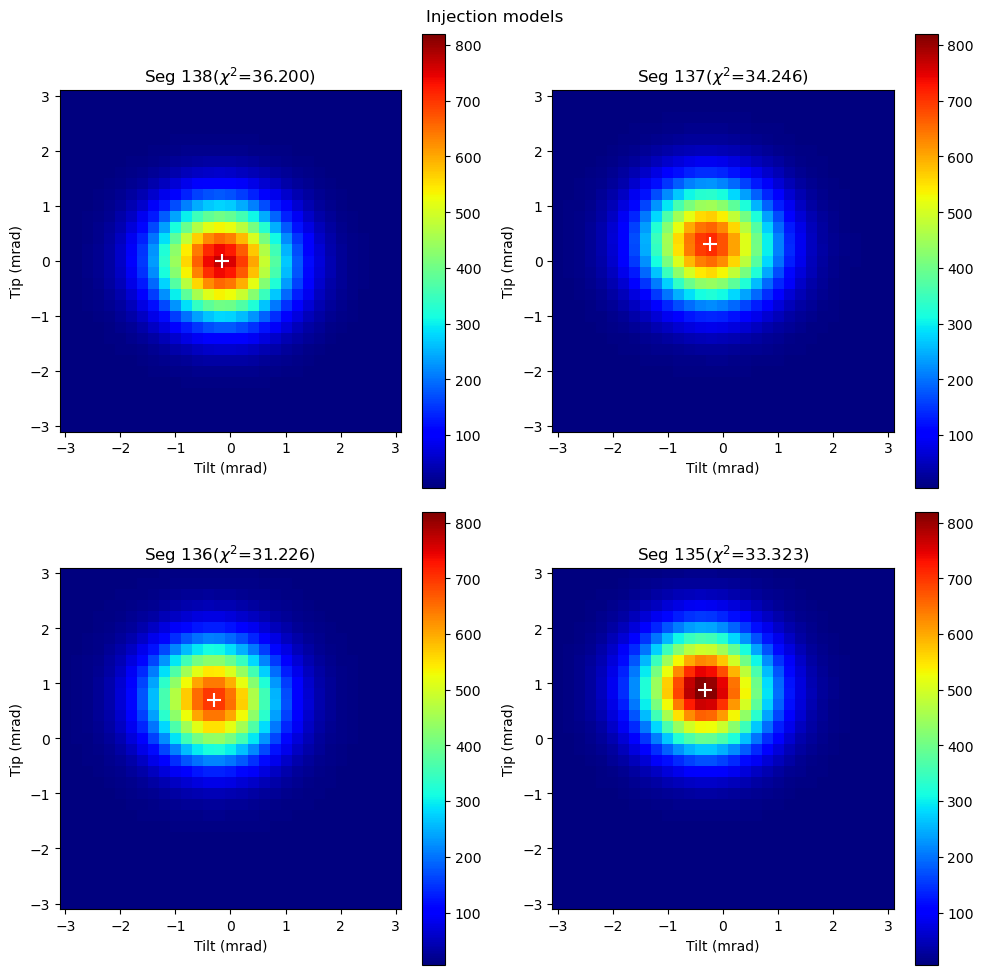

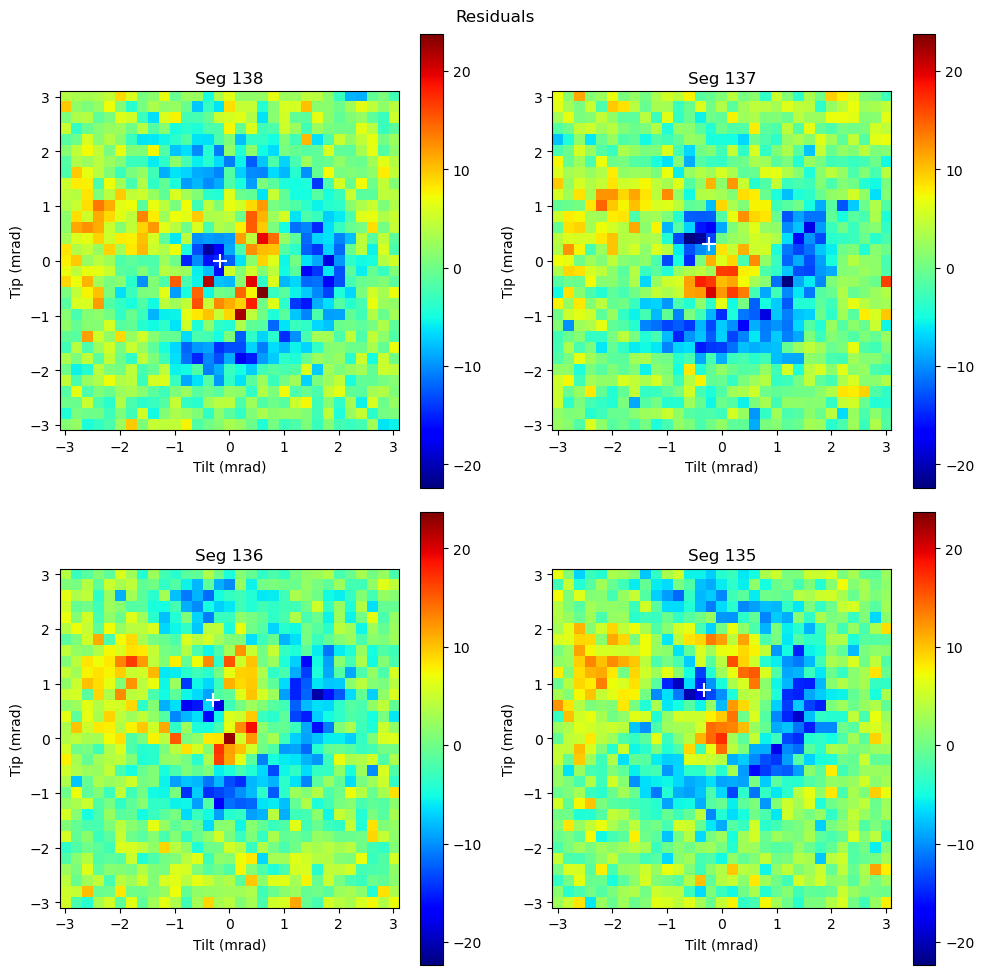

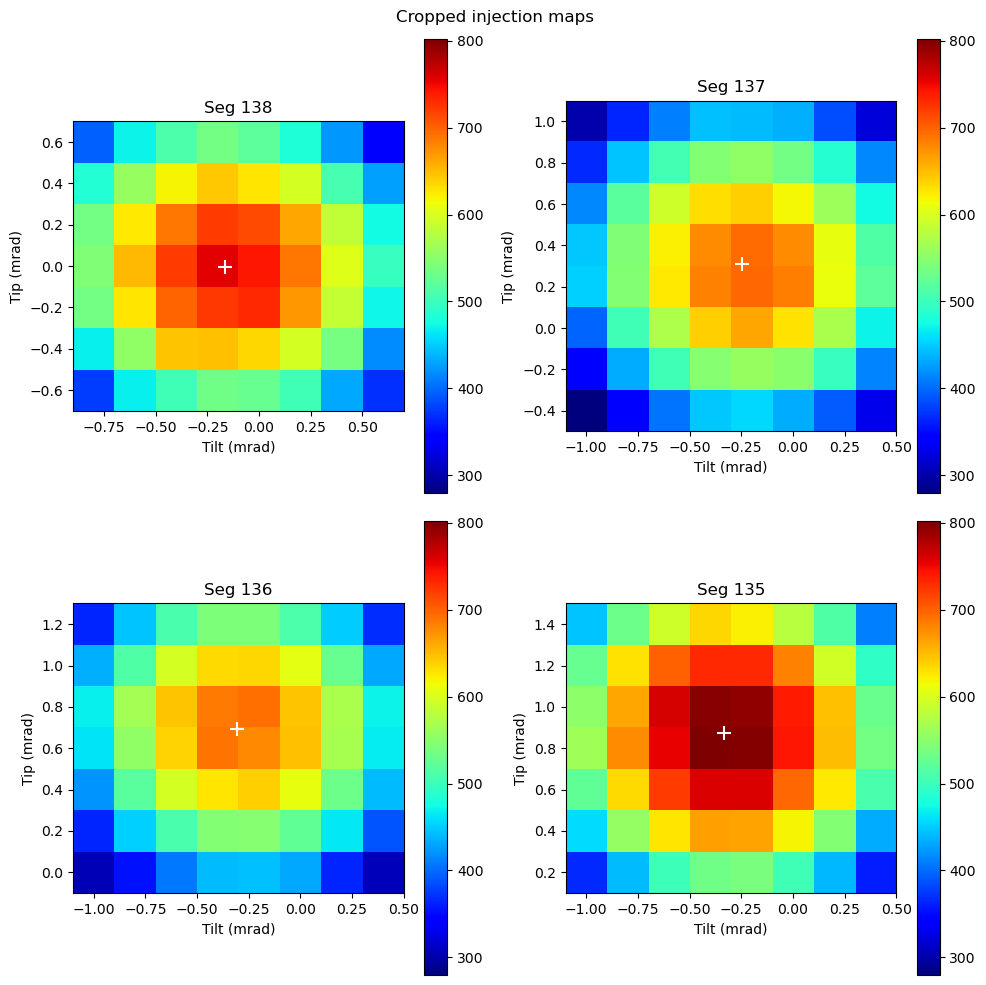

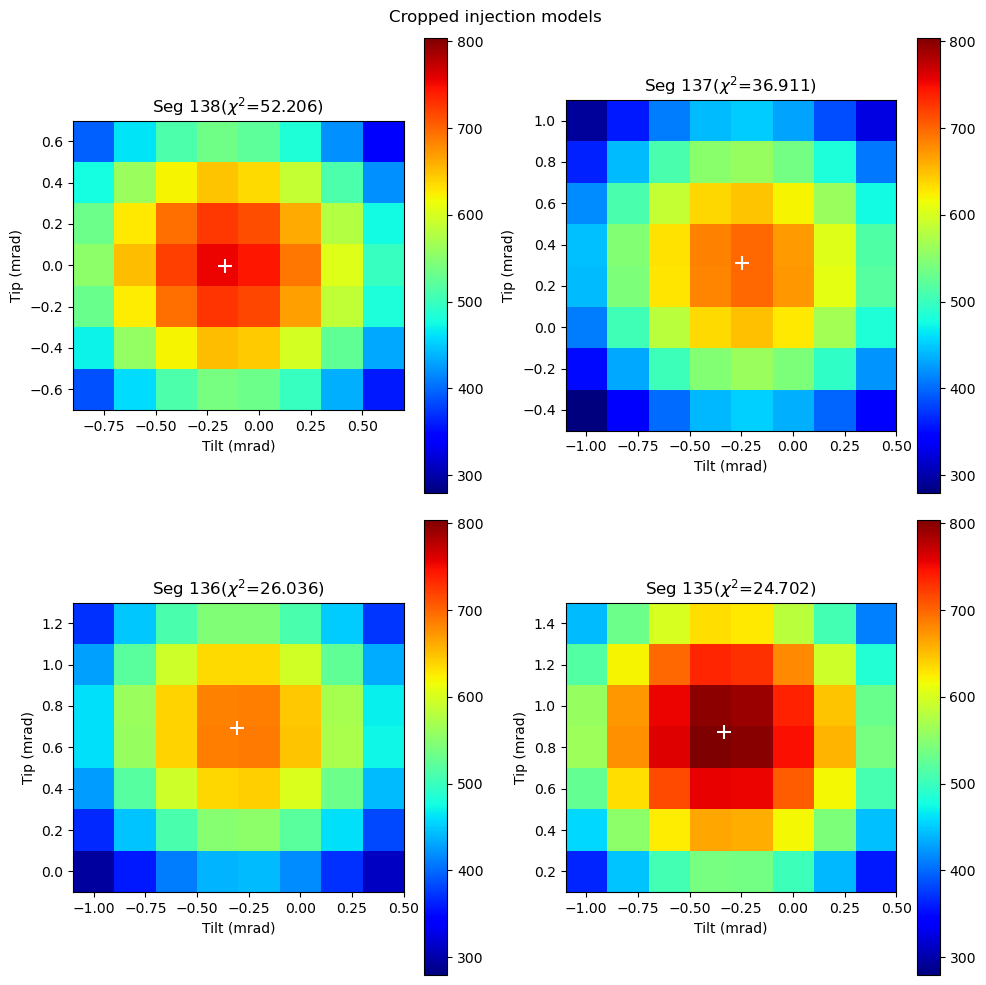

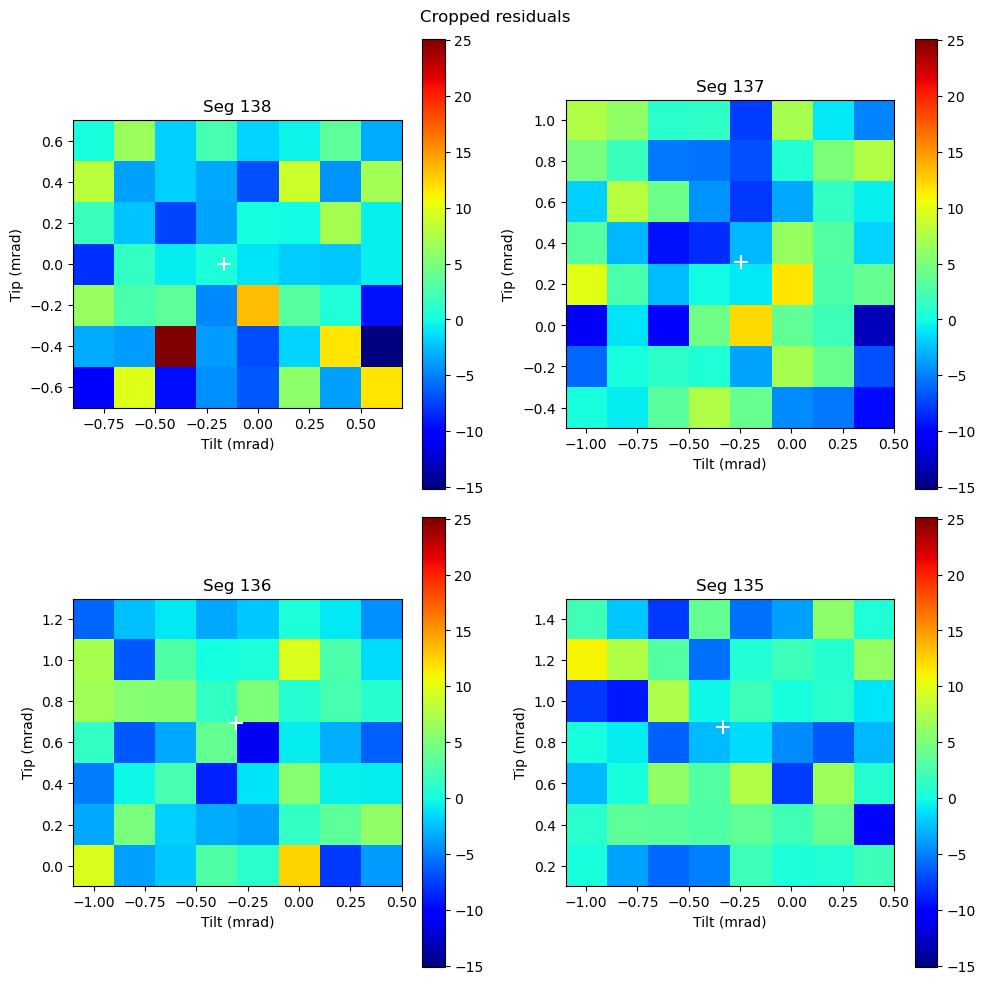

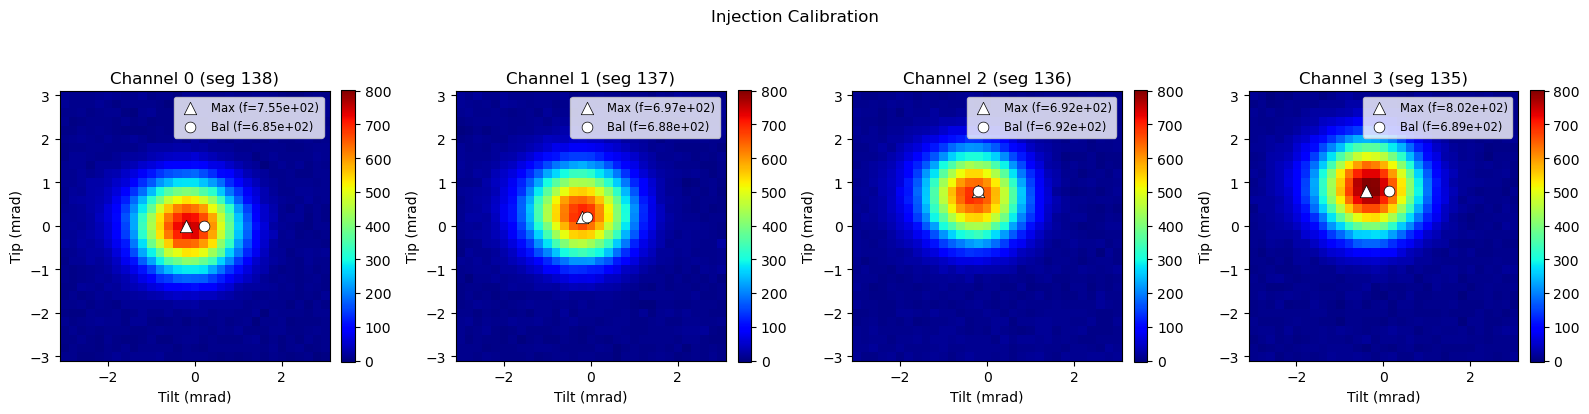

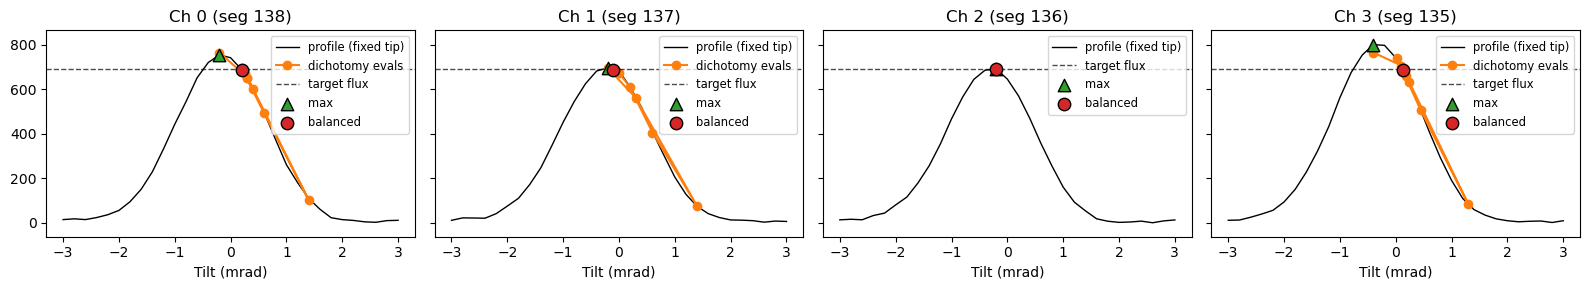

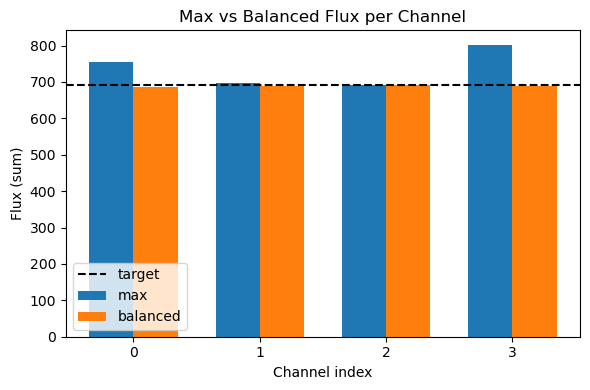

Successfully saved in FITS
Injection ZERO on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection ZERO on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
/dev/ttyS0 - ttyS0
/dev/ttyS1 - ttyS1
/dev/ttyUSBthorlabs - n/a
/dev/ttyUSBzaber - n/a
/dev/ttyUSBnewport - n/a
/dev/ttyUSB2 - CONEX-AGP - CONEX-AGP
/dev/ttyUSB1 - FW102CNEB - FW102CNEB
/dev/ttyUSB0 - FT232R USB UART - FT232R USB UART
/dev/ttyACM0 - Arduino Uno
Found Arduino
/dev/ttyS0 - ttyS0
/dev/ttyS1 - ttyS1
/dev/ttyUSBthorlabs - n/a
/dev/ttyUSBzaber - n/a
/dev/ttyUSBnewport - n/a
/dev/ttyUSB2 - CONEX-AGP - CONEX-AGP
/dev/ttyUSB1 - FW102CNEB - FW102CNEB
/dev/ttyUSB0 - FT232R USB UART - FT232R USB UART
/dev/ttyACM0 - Arduino Uno
Found Arduino
Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Starting stability test on Shifter 20 for 900.0s...
Target power (W) [0.29500178 0.30102184 0.29732448 0.297788  ]
Starting s

100%|██████████| 60/60 [14:59<00:00, 15.00s/it]



✅ Data saved to /mnt/disk1/archive/2026-04-20_fdfc996/1_topa_power/topa_stability_all_shifters_0.3W.npy



Scanning injection maps:   0%|          | 0/4 [00:00<?, ?it/s]

  Channel 0 (segment 138): scanning…
Injection OFF on channels [1, 2, 3] (segments [137, 136, 135])


...

Scanning injection maps:  75%|███████▌  | 3/4 [00:48<00:16, 16.41s/it]

Injection OFF on channels [2] (segments [136])
  Channel 3 (segment 135): scanning…
Injection OFF on channels [0, 1, 2] (segments [138, 137, 136])


Scanning injection maps: 100%|██████████| 4/4 [01:12<00:00, 18.15s/it]

Injection OFF on channels [3] (segments [135])
Injection FLAT on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])

── Find gross TT for max injection and spread ──
Injection spread of seg=138: (tip, tilt) = (0.69105,0.78956) mrad
Injection spread of seg=137: (tip, tilt) = (0.70723,0.78788) mrad
Injection spread of seg=136: (tip, tilt) = (0.69589,0.76677) mrad
Injection spread of seg=135: (tip, tilt) = (0.70807,0.77729) mrad

── Find precise TT for max injection ──
Injection max of seg=138: (tip, tilt) = (0.04485,0.24954) mrad; flux = 873.4
Injection max of seg=137: (tip, tilt) = (0.35583,0.15364) mrad; flux = 710.2
Injection max of seg=136: (tip, tilt) = (0.73921,0.07084) mrad; flux = 793.9
Injection max of seg=135: (tip, tilt) = (0.92167,0.03752) mrad; flux = 911.4
✅ Injection calibration saved to config (injection.max)



── Finding maximum injection points ──

── Balancing injection fluxes ──
  Weakest channel: 2 (seg 136), target flux = 727.2
  Dichotomy on channel 0 (seg 138)…
Injection OFF on channels [1, 2, 3] (segments [137, 136, 135])
    → balanced tilt = 0.5300 mrad, flux = 726.1 (target 727.2), iterations = 13
  Dichotomy on channel 1 (seg 137)…
Injection OFF on channels [0, 2, 3] (segments [138, 136, 135])
    → balanced tilt = 0.5300 mrad, flux = 726.1 (target 727.2), iterations = 13
  Dichotomy on channel 1 (seg 137)…
Injection OFF on channels [0, 2, 3] (segments [138, 136, 135])
    → balanced tilt = 0.3639 mrad, flux = 727.4 (target 727.2), iterations = 13
  Dichotomy on channel 3 (seg 135)…
Injection OFF on channels [0, 1, 2] (segments [138, 137, 136])
    → balanced tilt = 0.3639 mrad, flux = 727.4 (target 727.2), iterations = 13
  Dichotomy on channel 3 (seg 135)…
Injection OFF on channels [0, 1, 2] (segments [138, 137, 136])
    → balanced tilt = 0.5129 mrad, flux = 724.7 (target 727

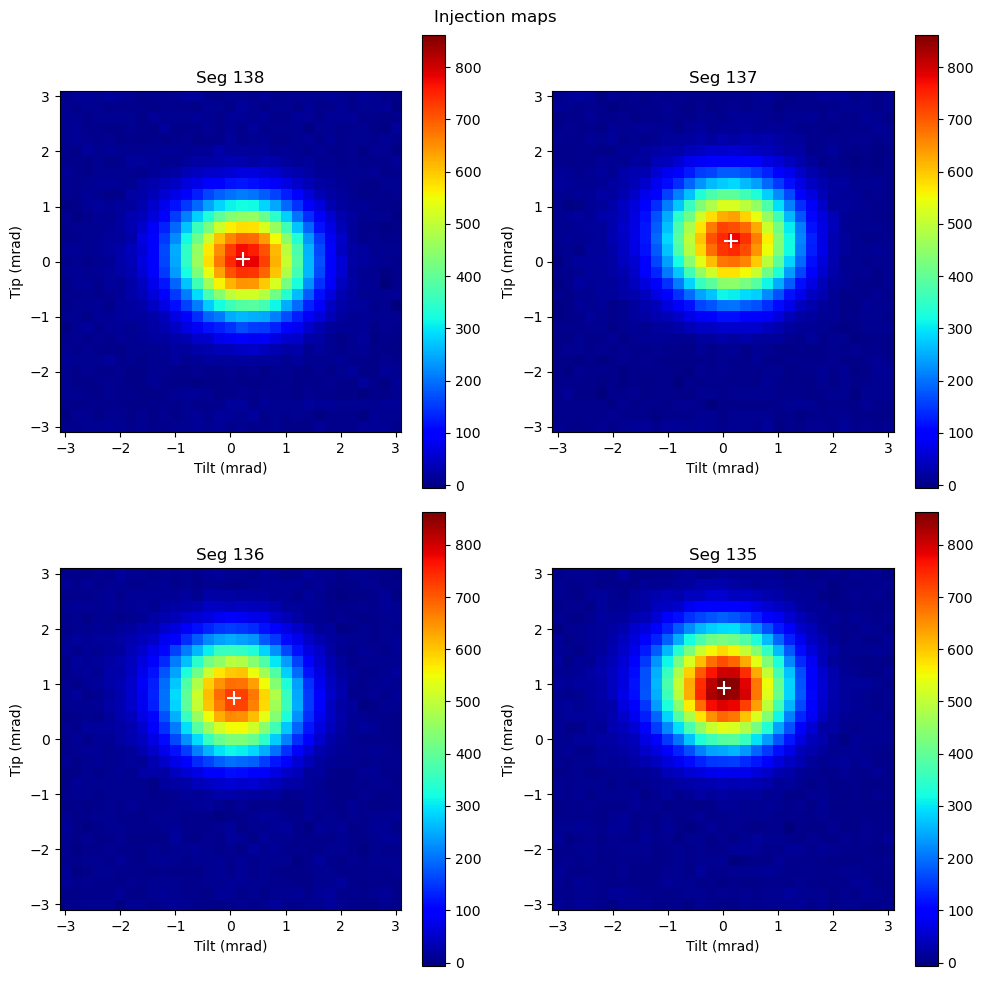

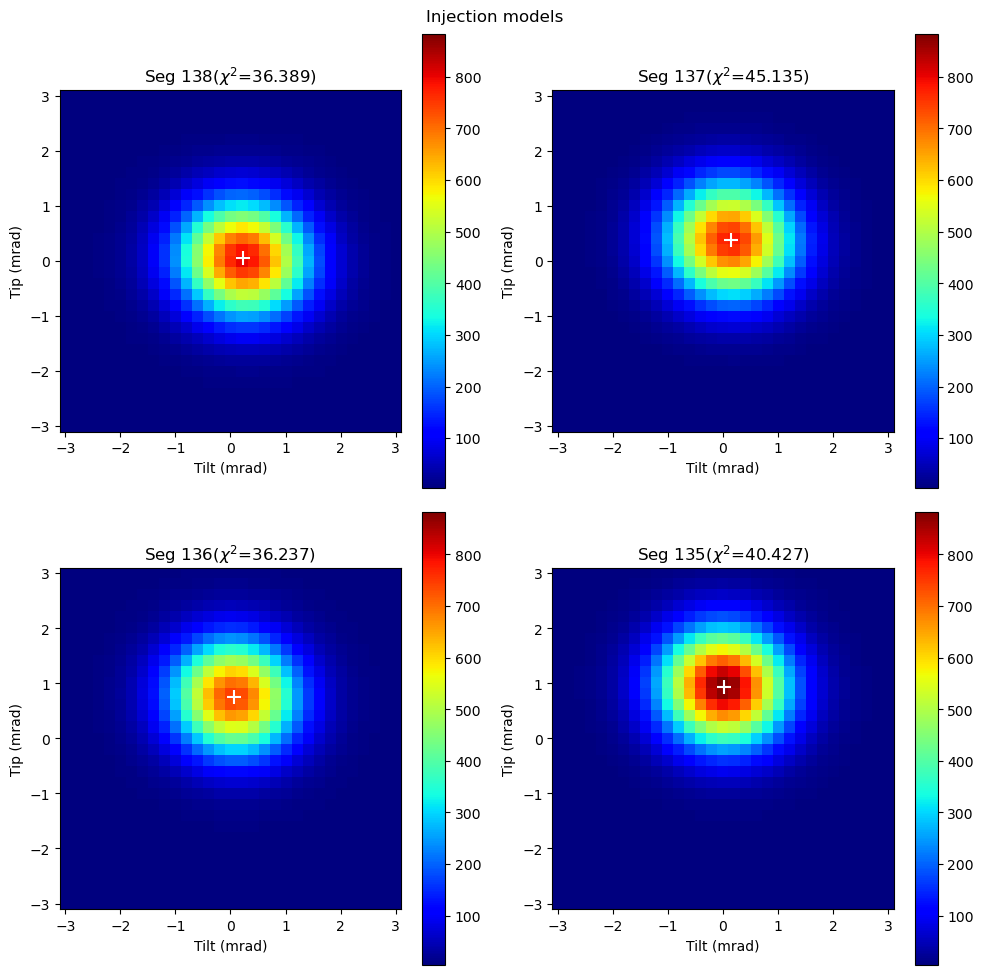

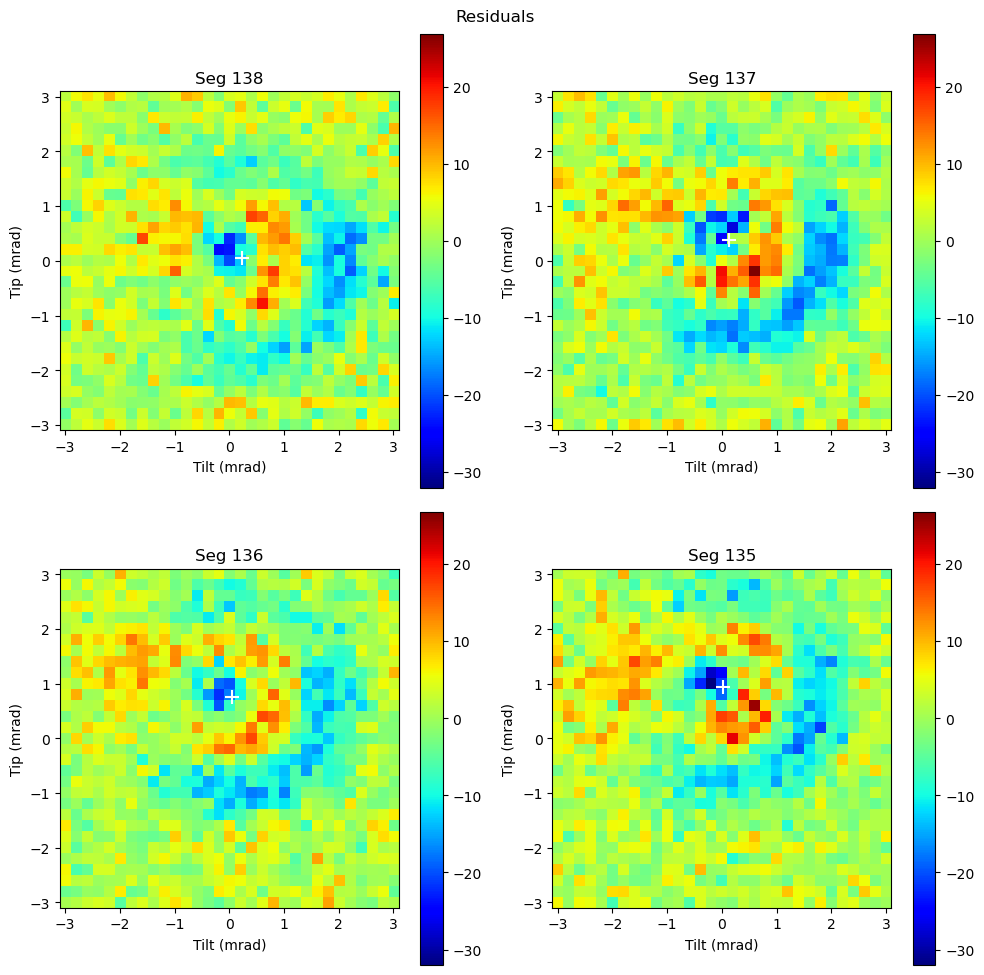

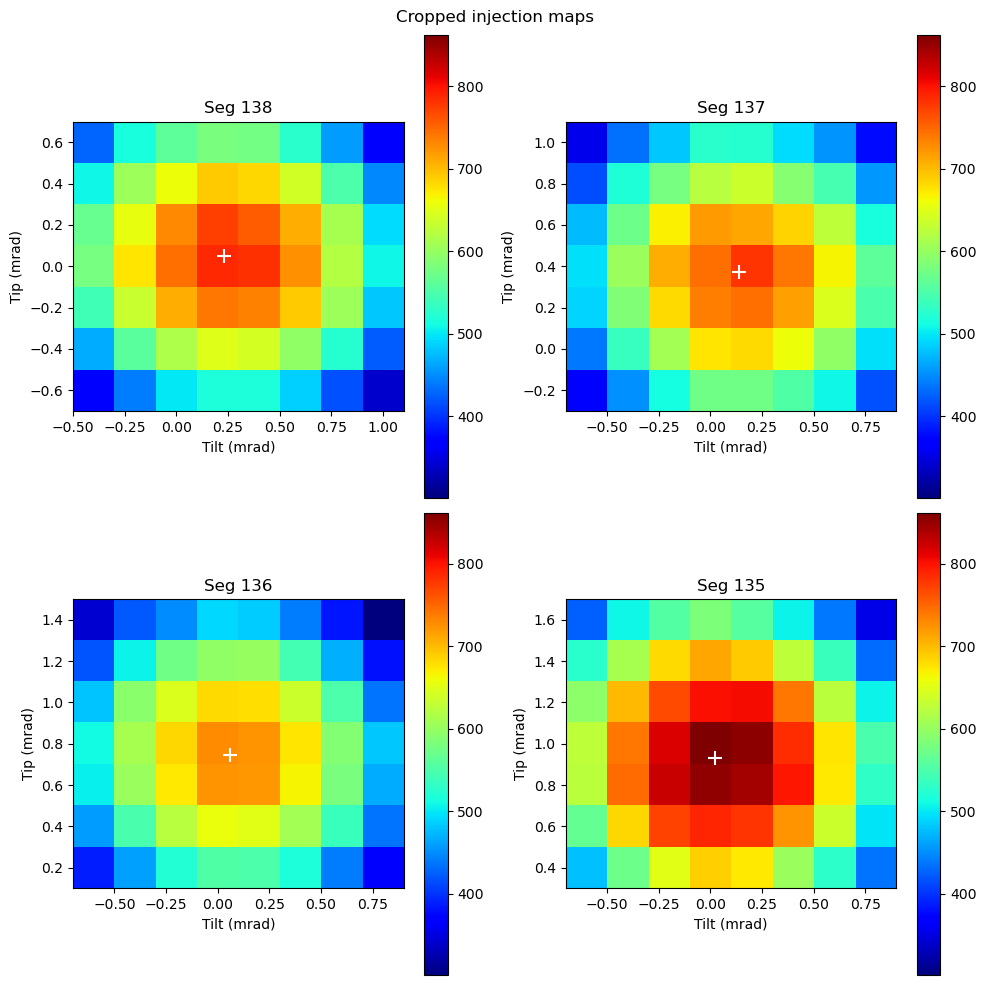

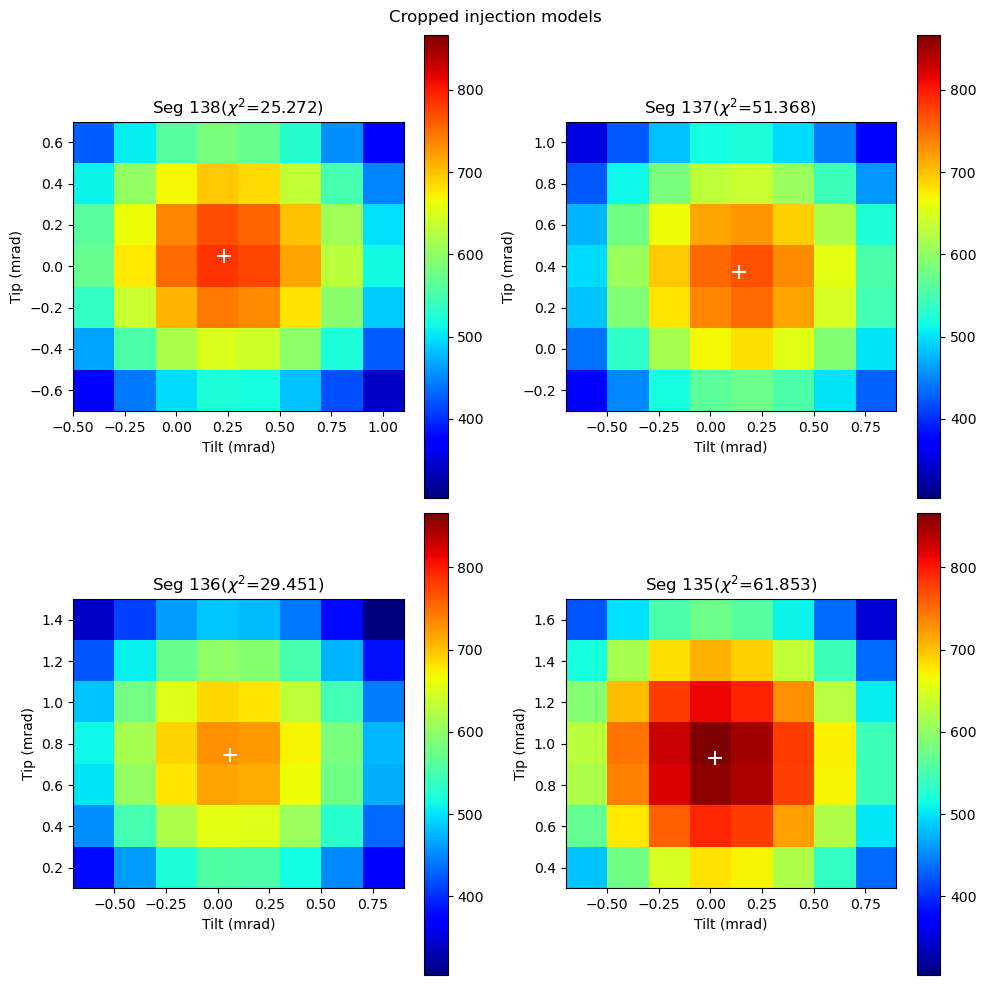

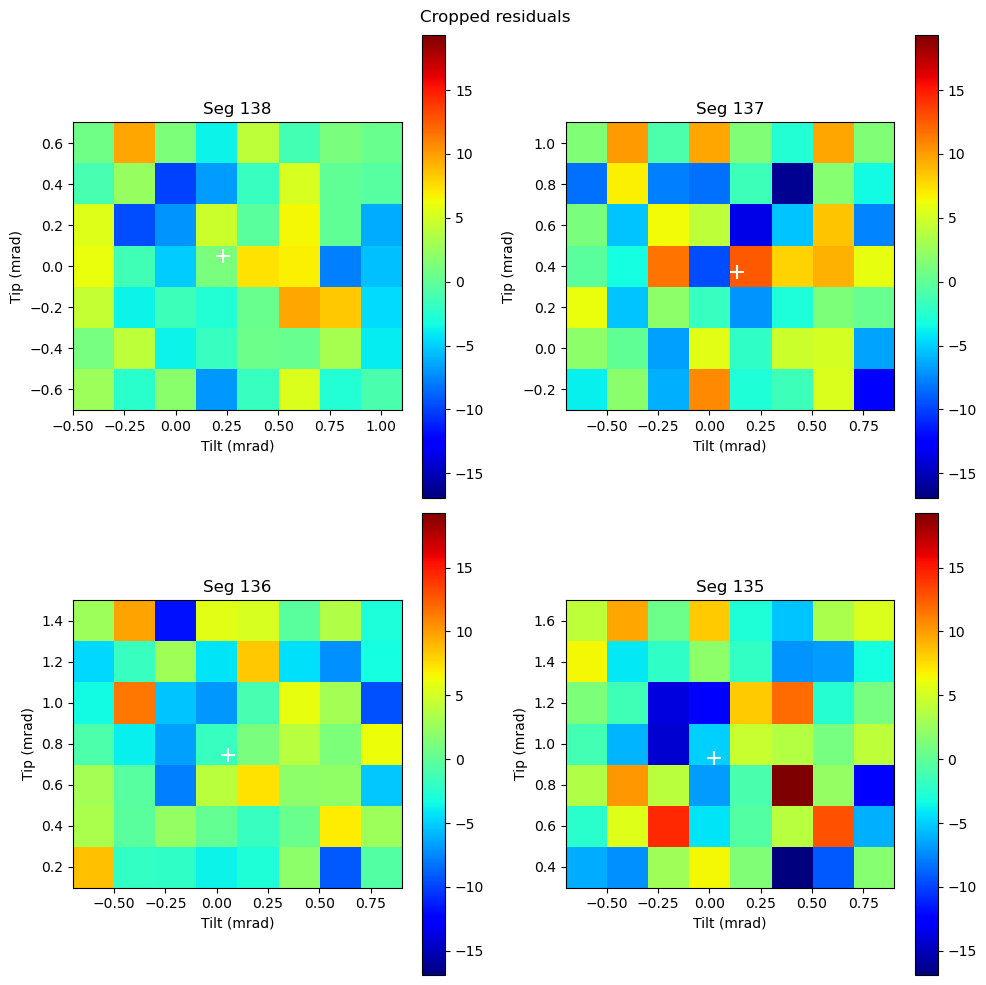

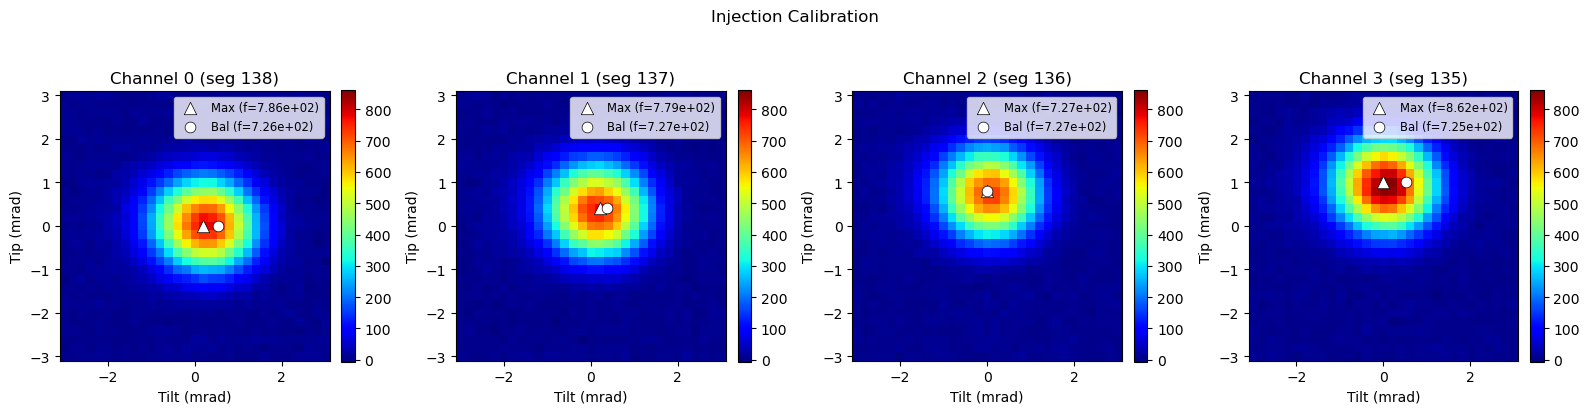

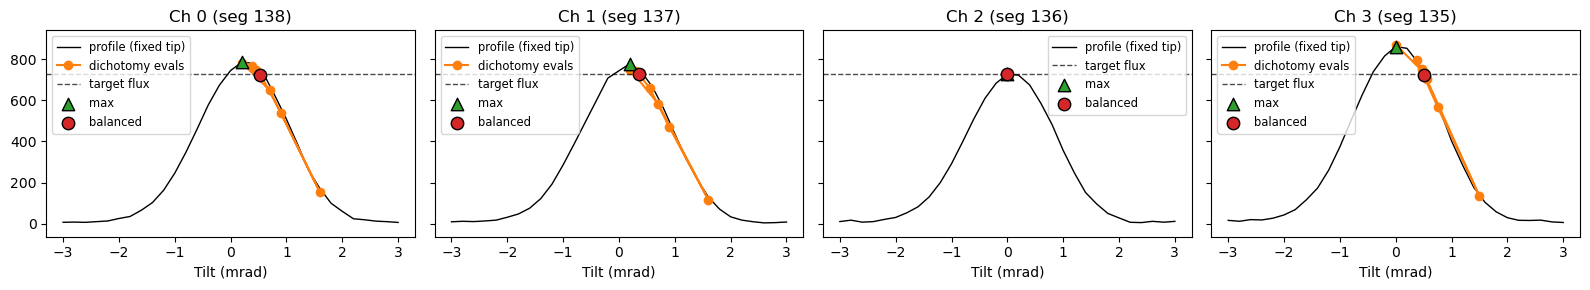

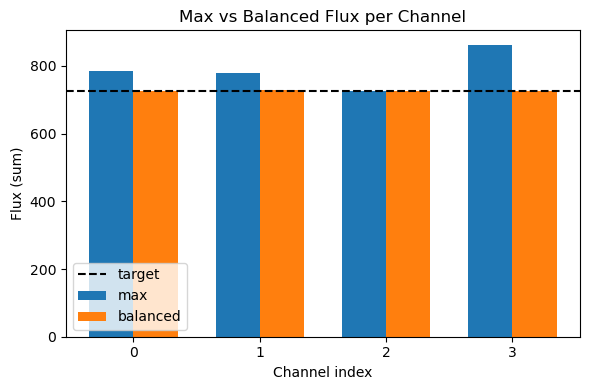

Successfully saved in FITS
Injection ZERO on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection ZERO on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


In [ ]:
# Injection calibration
avg_frame = 1
avg_frames_bal = 5
out_inj = inj.calibrate(verbose=True, plot=True, save_path=path, 
                        avg_frames=avg_frame, avg_frames_bal=avg_frames_bal,
                        tilt_tol=0.5e-3)

inj.zero()

filename = 'injection_values_before4ps_'+datetime.now().strftime("%Y-%m-%dT%H:%M:%S")+'.pkl'
with open(path / filename, 'wb') as f:
    pickle.dump(out_inj, f)


phobos.Config().set('injection.balanced', bal_list)
phobos.Config().set('injection.max', max_list)
phobos.Config().save_to_file()

# TOPA
dt = 0.25 # Image acquisition period in min
T_total = 15 # Total duration in min

nb_points = int(T_total // dt)

power_on_time = 5.0   # Time when the phase shifter turns ON (min)
power_off_time = 10.0  # Time when the phase shifter turns OFF (min)

dt *= 60.
T_total *= 60.
power_on_time *= 60.
power_off_time *= 60.

temp_probe = open_port()

# The target power is the mean power over a period as obtained from calibration
target_power = chip_coeffs[:, 1] / 2.

# Setup the bench
chip.turn_off()
inj.set_balanced()
time.sleep(1.0)

print(f"Starting stability test on Shifter {shifter.channel} for {T_total}s...")
print(f"Target power (W)", target_power)

datacube = []

is_on = False

# Loop for the duration of the experiment
start_time = time.time()
next_acq_time = start_time + dt
with tqdm(total=int(T_total/dt)) as pbar:
    while True:
        current_time = time.time()
        elapsed = current_time - start_time
        
        if elapsed >= T_total:
            break
            
        # Phase shifter activation logic
        if power_on_time <= elapsed < power_off_time:
            if not is_on:
                [shifter.set_power(target_power[i]) for i, shifter in enumerate(chip.shifters)]
                is_on = True
        else:
            if is_on:
                [shifter.turn_off() for shifter in chip.shifters]
                is_on = False
        
        current_powers = [shifter.get_power() for shifter in chip.shifters]        
            
        # Data acquisition
        actual_time = time.time()
        actual_elapsed = actual_time - start_time
        fluxes = cam.get_outputs(flux_mode='mean', stack=nb_frames)
        temperature = float(read_temp(temp_probe))

        # Save timestamp, applied power, and the output fluxes
        datacube.append([actual_elapsed, temperature, *target_power, *current_powers, *fluxes])

        # Wait until the next acquisition tick to keep the dt period
        now = time.time()
        if now < next_acq_time:
            time.sleep(next_acq_time - now)

        # Schedule next acquisition
        next_acq_time += dt
        pbar.update(1)

# Cleanup
chip.turn_off()

# Convert and save
datacube = np.array(datacube)
filename = 'topa_stability_all_shifters_%.1fW_%s.npy'%(target_power.mean(), datetime.now().strftime("%Y-%m-%dT%H:%M:%S"))
np.save(path / filename, datacube)
print(f"✅ Data saved to {path / filename}")
print('')

temp_probe.close()

# Injection calibration
avg_frame = 1
avg_frames_bal = 5
out_inj = inj.calibrate(verbose=True, plot=True, save_path=path, 
                        avg_frames=avg_frame, avg_frames_bal=avg_frames_bal,
                        tilt_tol=0.5e-3)

inj.zero()
filename = 'injection_values_after4ps_'+datetime.now().strftime("%Y-%m-%dT%H:%M:%S")+'.pkl'
with open(path / filename, 'wb') as f:
    pickle.dump(out_inj, f)

time.sleep(15*60.)
filename = 'injection_values_after4ps_cooldown_'+datetime.now().strftime("%Y-%m-%dT%H:%M:%S")+'.pkl'
with open(path / filename, 'wb') as f:
    pickle.dump(out_inj, f)

phobos.Config().set('injection.balanced', bal_list)
phobos.Config().set('injection.max', max_list)
phobos.Config().save_to_file()



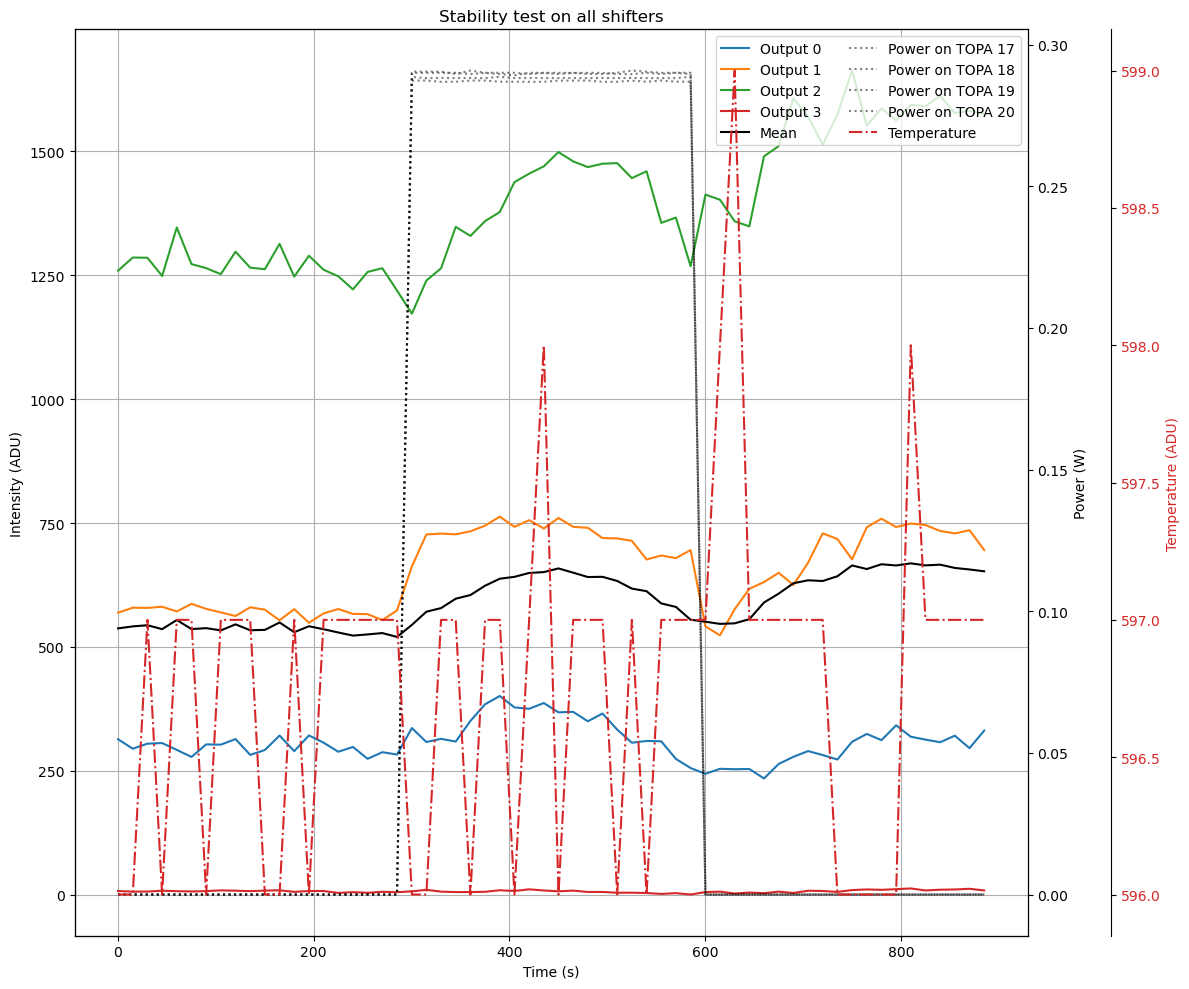

In [55]:
# Plot the result to verify
try:
    filename = 'topa_stability_all_shifters_%.1fW.npy'%(target_power.mean())
    datacube = np.load(path / filename)
    fluxes = datacube[:, -5:-1] - datacube[:, -1][:,None]
    temperature = datacube[:, 1]

    fig, ax1 = plt.subplots(figsize=(12, 10))
    plt.title("Stability test on all shifters")
    plot_cols = fluxes.shape[1]
    ax1.plot(datacube[:, 0], fluxes, label=[f'Output {i}' for i in range(plot_cols)])
    ax1.plot(datacube[:, 0], fluxes.mean(axis=1), label='Mean', color='k', linestyle='-')
    ax1.set_ylabel("Intensity (ADU)")
    ax1.set_xlabel("Time (s)")
    ax1.grid(True)

    # Plot the requested and applied power on a secondary axis
    ax2 = ax1.twinx()
    # ax2.plot(datacube[:, 0], datacube[:, 1], '--', color='k', alpha=0.5, label='Requested Power')
    ax2.plot(datacube[:, 0], datacube[:, 6:10], ':', color='k', alpha=0.5, label=['Power on TOPA %d' % i for i in range(17, 21)])
    ax2.set_ylabel("Power (W)")

    # Third axis for temperature
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))
    ax3.plot(datacube[:, 0], temperature, '-.', color='tab:red', label='Temperature')
    ax3.set_ylabel("Temperature (ADU)", color='tab:red')
    ax3.tick_params(axis='y', labelcolor='tab:red')

    # Combine legends from all axes
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    lines_3, labels_3 = ax3.get_legend_handles_labels()
    ax2.legend(lines_1 + lines_2 + lines_3, labels_1 + labels_2 + labels_3, loc='best', ncol=2)

    fig.tight_layout()
    figname = f'topa_stability_all_shifters_{target_power.mean():.1f}W.png'
    fig.savefig(path / figname, dpi=150)
except FileNotFoundError:
    pass

## 3 phase shifters

In [ ]:
# Injection calibration
avg_frame = 1
avg_frames_bal = 5
out_inj = inj.calibrate(verbose=True, plot=False, save_path=path, 
                        avg_frames=avg_frame, avg_frames_bal=avg_frames_bal,
                        tilt_tol=0.5e-3)

inj.zero()

filename = 'injection_values_before3ps_'+datetime.now().strftime("%Y-%m-%dT%H:%M:%S")+'.pkl'
with open(path / filename, 'wb') as f:
    pickle.dump(out_inj, f)

phobos.Config().set('injection.balanced', bal_list)
phobos.Config().set('injection.max', max_list)
phobos.Config().save_to_file()

print('')

# TOPA
triplets = [(0, 1, 2), (0, 1, 3), (0, 2, 3), (1, 2, 3)]
temp_probe = open_port()

nb_frames = 5

# Parameters for the stability test
dt = 0.25 # Image acquisition period in min
T_total = 20 # Total duration in min

power_on_time = 5.0   # Time when the phase shifter turns ON (min)
power_off_time = 10.0  # Time when the phase shifter turns OFF (min)

dt *= 60.
T_total *= 60.
power_on_time *= 60.
power_off_time *= 60.

for triplet in triplets:
    # Setup the bench
    chip.turn_off()
    inj.set_balanced()
    time.sleep(1.0)

    target_powers = [chip_coeffs[idx, 1] / 2. for idx in triplet]

    print(f"Starting stability test on Shifters {triplet} for {T_total}s...")
    print('Target powers are:', target_powers)

    datacube = []
    start_time = time.time()

    is_on = False
    current_powers = [0.0, 0.0, 0.0]

    # Loop for the duration of the experiment
    next_acq_time = start_time + dt
    with tqdm(total=int(T_total/dt)) as pbar:
        while True:
            current_time = time.time()
            elapsed = current_time - start_time
            
            if elapsed >= T_total:
                break
                
            # Phase shifter activation logic
            if power_on_time <= elapsed < power_off_time:
                if not is_on:
                    for i, idx in enumerate(triplet):
                        chip.shifters[idx].set_power(target_powers[i])
                    is_on = True
            else:
                if is_on:
                    for idx in triplet:
                        chip.shifters[idx].turn_off()
                    is_on = False

            current_powers = [chip.shifters[idx].get_power() for idx in triplet]

            # Data acquisition
            actual_time = time.time()
            actual_elapsed = actual_time - start_time
            fluxes = cam.get_outputs(flux_mode='mean', stack=nb_frames)
            temperature = float(read_temp(temp_probe))

            # Save timestamp, applied power, and the output fluxes
            datacube.append([actual_elapsed, temperature, *target_powers, *current_powers, *fluxes])

            # Wait until the next acquisition tick to keep the dt period
            now = time.time()
            if now < next_acq_time:
                time.sleep(next_acq_time - now)

            # Schedule next acquisition
            next_acq_time += dt
            pbar.update(1)

    # Cleanup
    chip.turn_off()

    # Convert and save
    datacube = np.array(datacube)
    filename = f'topa_stability_shifters_{chip.shifters[triplet[0]].channel}_{chip.shifters[triplet[1]].channel}_{chip.shifters[triplet[2]].channel}_{np.mean(target_powers):.1f}W_{datetime.now().strftime("%Y-%m-%dT%H:%M:%S")}.npy'
    np.save(path / filename, datacube)
    print(f"✅ Data saved to {path / filename}")
    print('')

temp_probe.close()
print('')
# Injection calibration
avg_frame = 1
avg_frames_bal = 5
out_inj = inj.calibrate(verbose=True, plot=False, save_path=path, 
                        avg_frames=avg_frame, avg_frames_bal=avg_frames_bal,
                        tilt_tol=0.5e-3)

inj.zero()

phobos.Config().set('injection.balanced', bal_list)
phobos.Config().set('injection.max', max_list)
phobos.Config().save_to_file()

filename = 'injection_values_after3ps_'+datetime.now().strftime("%Y-%m-%dT%H:%M:%S")+'.pkl'
with open(path / filename, 'wb') as f:
    pickle.dump(out_inj, f)

Scanning injection maps:   0%|          | 0/4 [00:00<?, ?it/s]

  Channel 0 (segment 138): scanning…
Injection OFF on channels [1, 2, 3] (segments [137, 136, 135])


Scanning injection maps:  25%|██▌       | 1/4 [00:17<00:53, 17.76s/it]

Injection OFF on channels [0] (segments [138])
  Channel 1 (segment 137): scanning…
Injection OFF on channels [0, 2, 3] (segments [138, 136, 135])


Scanning injection maps:  50%|█████     | 2/4 [00:31<00:31, 15.61s/it]

...

Injection OFF on channels [3] (segments [135])
Injection FLAT on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])

── Find gross TT for max injection and spread ──
Injection spread of seg=138: (tip, tilt) = (0.70988,0.81216) mrad
Injection spread of seg=137: (tip, tilt) = (0.72148,0.81382) mrad
Injection spread of seg=136: (tip, tilt) = (0.71391,0.79279) mrad
Injection spread of seg=135: (tip, tilt) = (0.72573,0.79250) mrad

── Find precise TT for max injection ──
Injection max of seg=138: (tip, tilt) = (0.02248,-0.23110) mrad; flux = 682.9
Injection max of seg=137: (tip, tilt) = (0.34039,-0.31574) mrad; flux = 599.1
Injection max of seg=136: (tip, tilt) = (0.70888,-0.36193) mrad; flux = 566.5
Injection max of seg=135: (tip, tilt) = (0.89439,-0.39209) mrad; flux = 783.1
✅ Injection calibration saved to config (injection.max)

── Finding maximum injection points ──

── Balancing injection fluxes ──
  Weakest channel: 2 (seg 136), target flux = 570.5
  Dichotomy on channel 0 (seg 13

    → balanced tilt = 0.0467 mrad, flux = 576.5 (target 570.5), iterations = 13
  Dichotomy on channel 1 (seg 137)…
Injection OFF on channels [0, 2, 3] (segments [138, 136, 135])
    → balanced tilt = -0.2139 mrad, flux = 566 (target 570.5), iterations = 13
  Dichotomy on channel 3 (seg 135)…
Injection OFF on channels [0, 1, 2] (segments [138, 137, 136])
    → balanced tilt = -0.2139 mrad, flux = 566 (target 570.5), iterations = 13
  Dichotomy on channel 3 (seg 135)…
Injection OFF on channels [0, 1, 2] (segments [138, 137, 136])
    → balanced tilt = 0.0302 mrad, flux = 564.9 (target 570.5), iterations = 13
Injection FLAT on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
✅ Injection calibration saved to config (injection.balanced)
Successfully saved in FITS
Injection ZERO on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])

/dev/ttyS0 - ttyS0
/dev/ttyS1 - ttyS1
/dev/ttyUSBthorlabs - n/a
/dev/ttyUSBzaber - n/a
/dev/ttyUSBnewport - n/a
/dev/ttyUSB2 - CONEX-AGP - CONEX-AGP
/de

Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Starting stability test on Shifters (0, 1, 2) for 1200.0s...
Target powers are: [np.float64(0.29655507013375315), np.float64(0.30018506516590093), np.float64(0.29835502696847677)]
Starting stability test on Shifters (0, 1, 2) for 1200.0s...
Target powers are: [np.float64(0.29655507013375315), np.float64(0.30018506516590093), np.float64(0.29835502696847677)]


100%|██████████| 80/80 [19:59<00:00, 15.00s/it]



OSError: [Errno 36] File name too long: '/mnt/disk1/archive/2026-04-21_fdfc996/1_topa_power/topa_stability_shifters_<phobos.classes.photonic_chip.phase_shifter.PhaseShifter object at 0x7f243deb9370>_<phobos.classes.photonic_chip.phase_shifter.PhaseShifter object at 0x7f243dda9760>_<phobos.classes.photonic_chip.phase_shifter.PhaseShifter object at 0x7f243ddaa7e0>_0.3W_2026-04-21T17:21:04.npy'

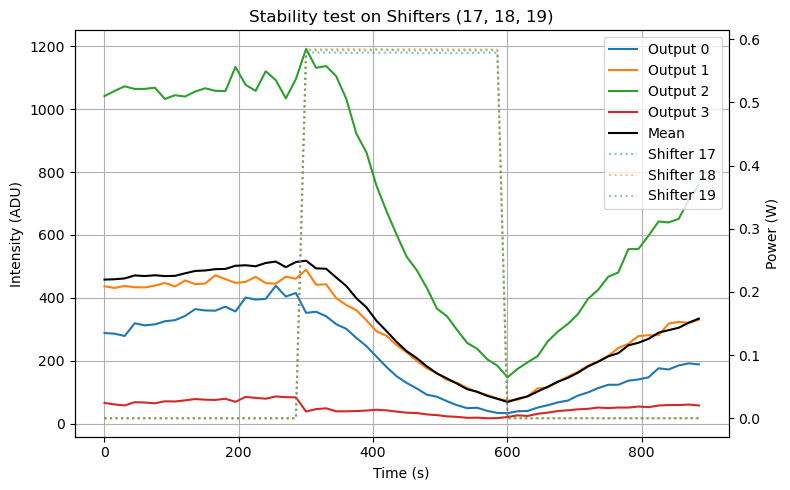

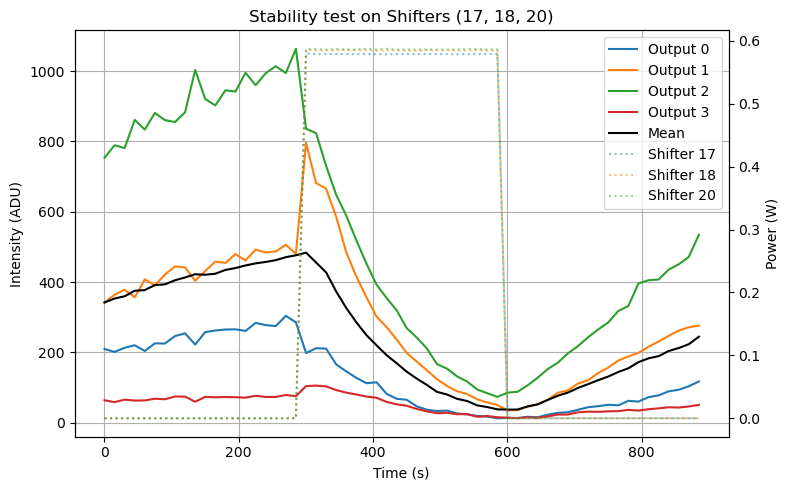

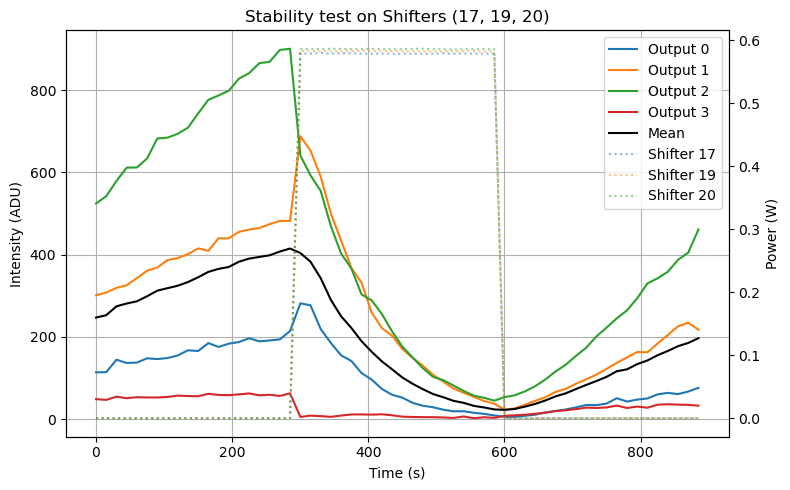

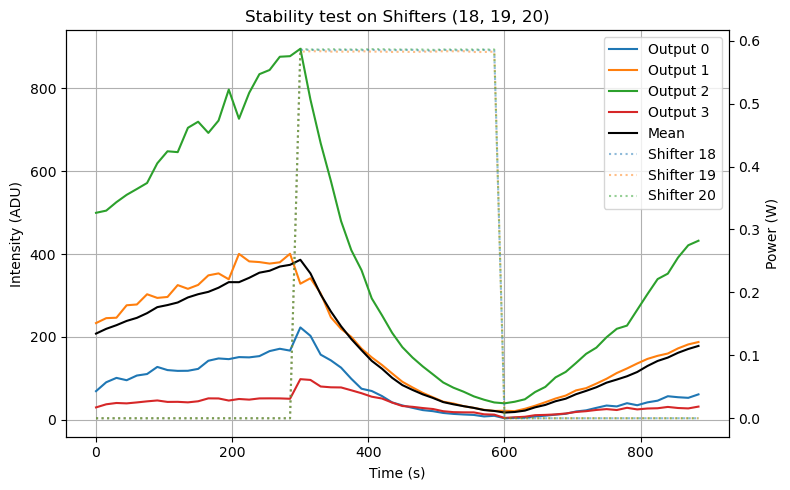

In [ ]:
def find_file(directory, base_name):
    """
    Find a file matching the base name followed by a timestamp.

    Parameters
    ----------
    directory : pathlib.Path
        The directory to search in.
    base_name : str
        The base string of the file before the timestamp (without extension).

    Returns
    -------
    pathlib.Path
        The path to the most recent matching file.

    Raises
    ------
    FileNotFoundError
        If no matching file is found.
    """
    matches = list(directory.glob(f"{base_name}_*.npy"))
    if not matches:
        raise FileNotFoundError(f"No file matching {base_name}_*.npy found.")
    
    # Return the most recent file if there are multiple matches
    return sorted(matches)[-1].name

# Plot the result to verify
triplets = [(0, 1, 2), (0, 1, 3), (0, 2, 3), (1, 2, 3)]

for tri in triplets:
    try:
        filename = f'topa_stability_shifters_{chip.shifters[tri[0]].channel}_{chip.shifters[tri[1]].channel}_{chip.shifters[tri[2]].channel}_{np.mean(target_powers):.1f}W'
        filename = find_file(path, filename)
        datacube = np.load(path / filename)
        fluxes = datacube[:, -5:-1] - datacube[:, -1][:,None]

        fig, ax1 = plt.subplots(figsize=(8, 5))
        plt.title(f"Stability test on Shifters {chip.shifters[tri[0]].channel, chip.shifters[tri[1]].channel, chip.shifters[tri[2]].channel}")
        plot_cols = fluxes.shape[1]
        ax1.plot(datacube[:, 0], fluxes, label=[f'Output {i}' for i in range(plot_cols)])
        ax1.plot(datacube[:, 0], fluxes.mean(axis=1), label='Mean', color='k', linestyle='-')
        ax1.set_ylabel("Intensity (ADU)")
        ax1.set_xlabel("Time (s)")
        ax1.grid(True)

        # Plot the requested and applied power on a secondary axis
        ax2 = ax1.twinx()
        # ax2.plot(datacube[:, 0], datacube[:, 1], '--', color='k', alpha=0.5, label='Requested Power')
        ax2.plot(datacube[:, 0], datacube[:, 5:8], ':', alpha=0.5, label=[f'Shifter {chip.shifters[i].channel}' for i in tri])
        ax2.set_ylabel("Power (W)")

        # Combine legends from both axes
        lines_1, labels_1 = ax1.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best')

        fig.tight_layout()
        figname = f'topa_stability_shifters{chip.shifters[tri[0]].channel}-{chip.shifters[tri[1]].channel}-{chip.shifters[tri[2]].channel}_{np.mean(target_powers):.1f}W.png'
        fig.savefig(path / figname, dpi=150)
    except FileNotFoundError:
        pass

## 2 Phase shifters

In [60]:
temp_probe = open_port()
print(read_temp(temp_probe))
temp_probe.close()
chip.turn_off()

/dev/ttyS0 - ttyS0
/dev/ttyS1 - ttyS1
/dev/ttyUSBthorlabs - n/a
/dev/ttyUSBzaber - n/a
/dev/ttyUSBnewport - n/a
/dev/ttyUSB2 - CONEX-AGP - CONEX-AGP
/dev/ttyUSB1 - FW102CNEB - FW102CNEB
/dev/ttyUSB0 - FT232R USB UART - FT232R USB UART
/dev/ttyACM0 - Arduino Uno
Found Arduino




In [ ]:
# Injection calibration
avg_frame = 1
avg_frames_bal = 5
out_inj = inj.calibrate(verbose=True, plot=False, save_path=path, 
                        avg_frames=avg_frame, avg_frames_bal=avg_frames_bal,
                        tilt_tol=0.5e-3)

inj.zero()

phobos.Config().set('injection.balanced', bal_list)
phobos.Config().set('injection.max', max_list)
phobos.Config().save_to_file()

filename = 'injection_values_before2ps_'+datetime.now().strftime("%Y-%m-%dT%H:%M:%S")+'.pkl'
with open(path / filename, 'wb') as f:
    pickle.dump(out_inj, f)

# TOPA
pairs = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
temp_probe = open_port()

print('Temperature is', read_temp(temp_probe))

nb_frames = 5

# Parameters for the stability test
dt = 0.25 # Image acquisition period in min
T_total = 20 # Total duration in min

power_on_time = 5.0   # Time when the phase shifter turns ON (min)
power_off_time = 10.0  # Time when the phase shifter turns OFF (min)

dt *= 60.
T_total *= 60.
power_on_time *= 60.
power_off_time *= 60.

for pair in pairs:
    # Setup the bench
    chip.turn_off()
    inj.set_balanced()
    time.sleep(1.0)

    target_powers = [chip_coeffs[idx, 1] / 2. for idx in pair]

    print(f"Starting stability test on Shifters {pair} for {T_total}s...")
    print('Target powers are:', target_powers)

    datacube = []
    start_time = time.time()

    is_on = False
    current_powers = [0.0, 0.0]

    # Loop for the duration of the experiment
    next_acq_time = start_time + dt
    with tqdm(total=int(T_total/dt)) as pbar:
        while True:
            current_time = time.time()
            elapsed = current_time - start_time
            
            if elapsed >= T_total:
                break
                
            # Phase shifter activation logic
            if power_on_time <= elapsed < power_off_time:
                if not is_on:
                    for i, idx in enumerate(pair):
                        chip.shifters[idx].set_power(target_powers[i])
                    is_on = True
            else:
                if is_on:
                    for idx in pair:
                        chip.shifters[idx].turn_off()
                    is_on = False

            current_powers = [chip.shifters[idx].get_power() for idx in pair]

            # Data acquisition
            actual_time = time.time()
            actual_elapsed = actual_time - start_time
            fluxes = cam.get_outputs(flux_mode='mean', stack=nb_frames)
            temperature = float(read_temp(temp_probe))

            # Save timestamp, applied power, and the output fluxes
            datacube.append([actual_elapsed, temperature, *target_powers, *current_powers, *fluxes])

            # Wait until the next acquisition tick to keep the dt period
            now = time.time()
            if now < next_acq_time:
                time.sleep(next_acq_time - now)

            # Schedule next acquisition
            next_acq_time += dt
            pbar.update(1)

    # Cleanup
    chip.turn_off()

    # Convert and save
    datacube = np.array(datacube)
    filename = f'topa_stability_shifters_{chip.shifters[pair[0]].channel}_{chip.shifters[pair[1]].channel}_{np.mean(target_powers):.1f}W_{datetime.now().strftime("%Y-%m-%dT%H:%M:%S")}.npy'
    np.save(path / filename, datacube)
    print(f"✅ Data saved to {path / filename}")
    print('')

print('At the end, temperature is', read_temp(temp_probe))
temp_probe.close()

# Injection calibration
avg_frame = 1
avg_frames_bal = 5
out_inj = inj.calibrate(verbose=True, plot=False, save_path=path, 
                        avg_frames=avg_frame, avg_frames_bal=avg_frames_bal,
                        tilt_tol=0.5e-3)

inj.zero()

phobos.Config().set('injection.balanced', bal_list)
phobos.Config().set('injection.max', max_list)
phobos.Config().save_to_file()

filename = 'injection_values_after2ps_'+datetime.now().strftime("%Y-%m-%dT%H:%M:%S")+'.pkl'
with open(path / filename, 'wb') as f:
    pickle.dump(out_inj, f)

Scanning injection maps:   0%|          | 0/4 [00:00<?, ?it/s]

  Channel 0 (segment 138): scanning…
Injection OFF on channels [1, 2, 3] (segments [137, 136, 135])


Scanning injection maps:  25%|██▌       | 1/4 [00:16<00:50, 16.73s/it]

Injection OFF on channels [0] (segments [138])
  Channel 1 (segment 137): scanning…
Injection OFF on channels [0, 2, 3] (segments [138, 136, 135])


Scanning injection maps:  50%|█████     | 2/4 [00:32<00:32, 16.03s/it]

...

Scanning injection maps:  75%|███████▌  | 3/4 [00:52<00:18, 18.35s/it]

Injection OFF on channels [2] (segments [136])
  Channel 3 (segment 135): scanning…
Injection OFF on channels [0, 1, 2] (segments [138, 137, 136])


Scanning injection maps: 100%|██████████| 4/4 [01:12<00:00, 18.00s/it]

Injection OFF on channels [3] (segments [135])
Injection FLAT on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])

── Find gross TT for max injection and spread ──
Injection spread of seg=138: (tip, tilt) = (0.70718,0.81123) mrad
Injection spread of seg=137: (tip, tilt) = (0.72119,0.81457) mrad
Injection spread of seg=136: (tip, tilt) = (0.71446,0.79091) mrad
Injection spread of seg=135: (tip, tilt) = (0.71802,0.79044) mrad

── Find precise TT for max injection ──
Injection max of seg=138: (tip, tilt) = (0.03569,-0.00497) mrad; flux = 569.3
Injection max of seg=137: (tip, tilt) = (0.35936,-0.09790) mrad; flux = 617
Injection max of seg=136: (tip, tilt) = (0.73224,-0.16042) mrad; flux = 501.9
Injection max of seg=135: (tip, tilt) = (0.92806,-0.19706) mrad; flux = 631.1
✅ Injection calibration saved to config (injection.max)

── Finding maximum injection points ──

── Balancing injection fluxes ──
  Weakest channel: 1 (seg 137), target flux = 545.5
  Dichotomy on channel 0 (seg 138)

    → balanced tilt = 0.2833 mrad, flux = 545.5 (target 545.5), iterations = 13
  Dichotomy on channel 2 (seg 136)…
Injection OFF on channels [0, 1, 3] (segments [138, 137, 135])
    → balanced tilt = -0.0244 mrad, flux = 548.3 (target 545.5), iterations = 13
  Dichotomy on channel 3 (seg 135)…
Injection OFF on channels [0, 1, 2] (segments [138, 137, 136])
    → balanced tilt = -0.0244 mrad, flux = 548.3 (target 545.5), iterations = 13
  Dichotomy on channel 3 (seg 135)…
Injection OFF on channels [0, 1, 2] (segments [138, 137, 136])
    → balanced tilt = -0.6948 mrad, flux = 544.9 (target 545.5), iterations = 13
Injection FLAT on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
✅ Injection calibration saved to config (injection.balanced)
Successfully saved in FITS
Injection ZERO on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
    → balanced tilt = -0.6948 mrad, flux = 544.9 (target 545.5), iterations = 13
Injection FLAT on channels [0, 1, 2, 3] (segments [138, 137, 136, 1

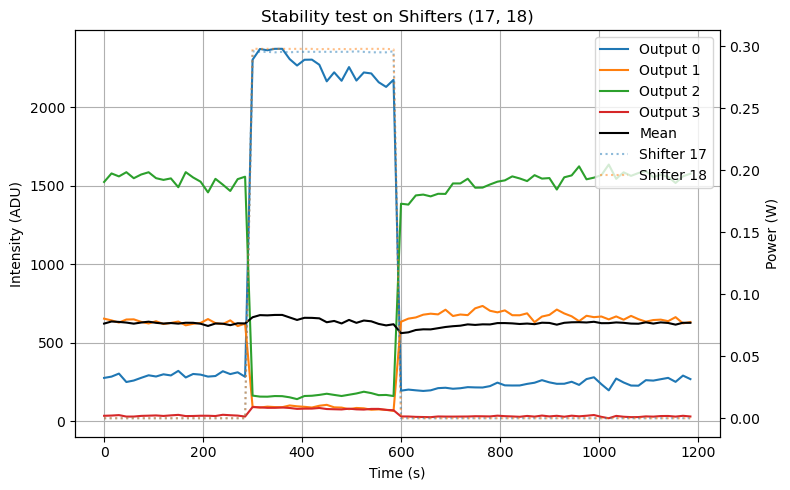

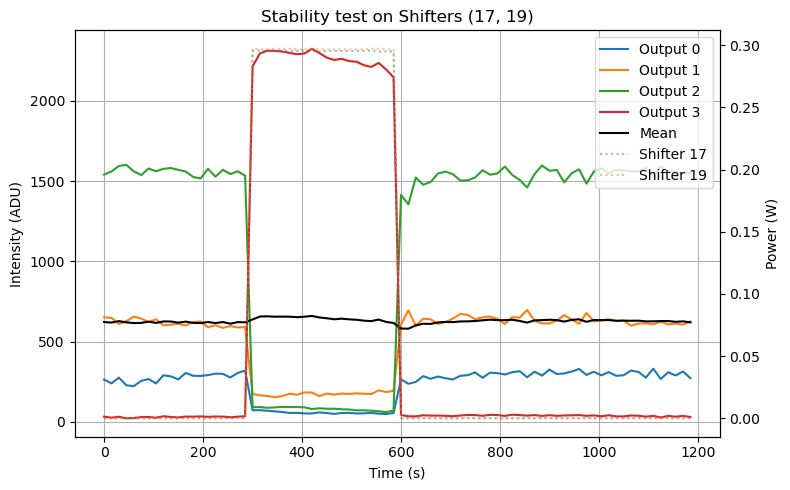

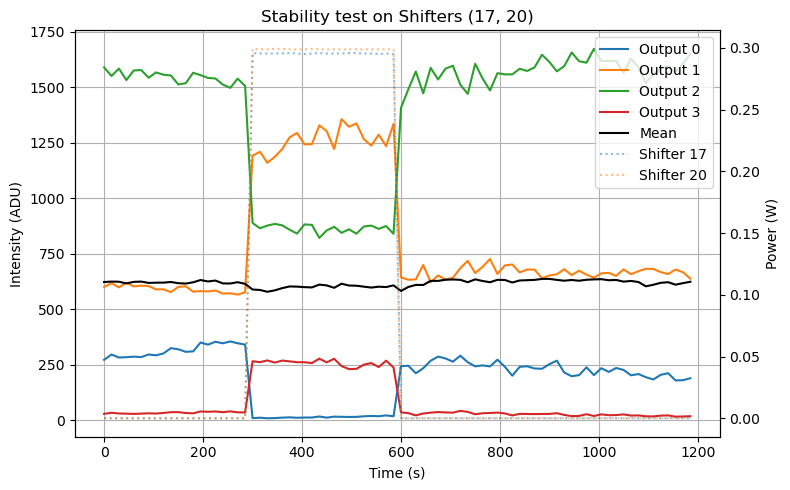

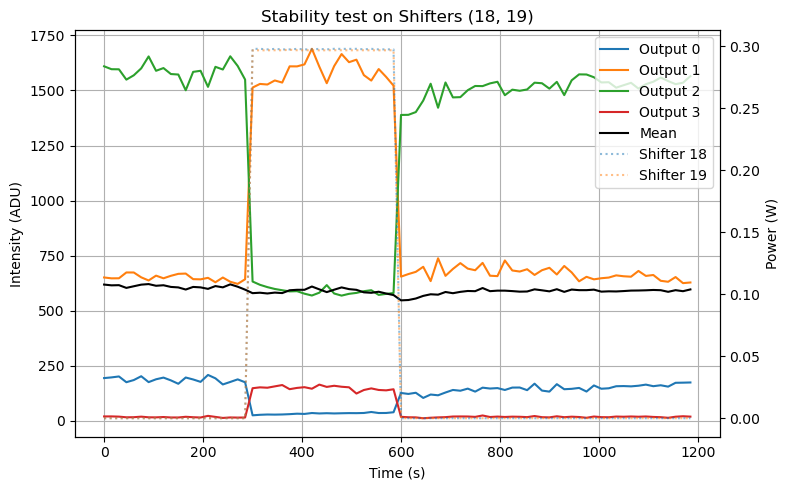

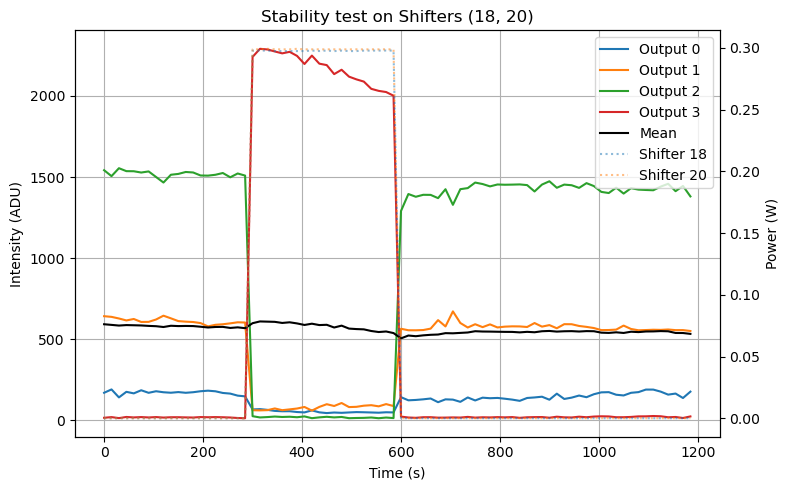

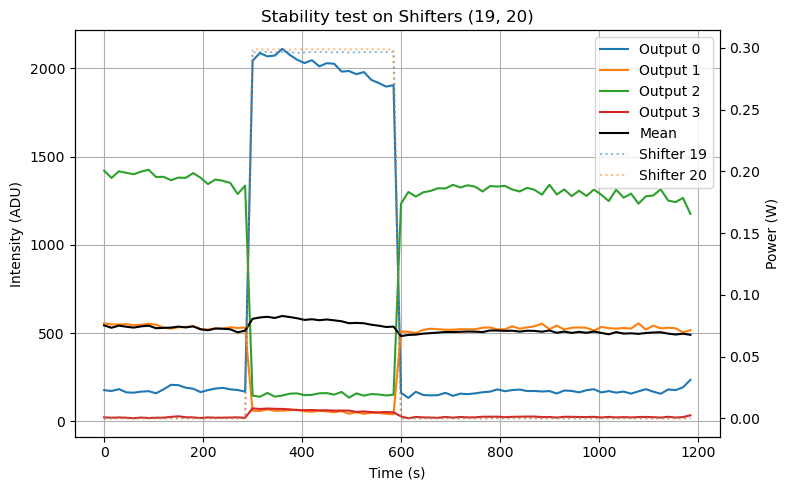

In [ ]:
def find_file(directory, base_name):
    """
    Find a file matching the base name followed by a timestamp.

    Parameters
    ----------
    directory : pathlib.Path
        The directory to search in.
    base_name : str
        The base string of the file before the timestamp (without extension).

    Returns
    -------
    pathlib.Path
        The path to the most recent matching file.

    Raises
    ------
    FileNotFoundError
        If no matching file is found.
    """
    matches = list(directory.glob(f"{base_name}_*.npy"))
    if not matches:
        raise FileNotFoundError(f"No file matching {base_name}_*.npy found.")
    
    # Return the most recent file if there are multiple matches
    return sorted(matches)[-1].name

# Plot the result to verify
pairs = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]

for pair in pairs:
    try:
        filename = f'topa_stability_shifters_{chip.shifters[pair[0]].channel}_{chip.shifters[pair[1]].channel}_{np.mean(target_powers):.1f}W'
        filename = find_file(path, filename)
        datacube = np.load(path / filename)
        fluxes = datacube[:, -5:-1] - datacube[:, -1][:,None]

        fig, ax1 = plt.subplots(figsize=(8, 5))
        plt.title(f"Stability test on Shifters {chip.shifters[pair[0]].channel, chip.shifters[pair[1]].channel}")
        plot_cols = fluxes.shape[1]
        ax1.plot(datacube[:, 0], fluxes, label=[f'Output {i}' for i in range(plot_cols)])
        ax1.plot(datacube[:, 0], fluxes.mean(axis=1), label='Mean', color='k', linestyle='-')
        ax1.set_ylabel("Intensity (ADU)")
        ax1.set_xlabel("Time (s)")
        ax1.grid(True)

        # Plot the requested and applied power on a secondary axis
        ax2 = ax1.twinx()
        # ax2.plot(datacube[:, 0], datacube[:, 1], '--', color='k', alpha=0.5, label='Requested Power')
        ax2.plot(datacube[:, 0], datacube[:, 4:6], ':', alpha=0.5, label=[f'Shifter {chip.shifters[i].channel}' for i in pair])
        ax2.set_ylabel("Power (W)")

        # Combine legends from both axes
        lines_1, labels_1 = ax1.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best')

        fig.tight_layout()
        figname = f'topa_stability_shifters{chip.shifters[pair[0]].channel}-{chip.shifters[pair[1]].channel}_{np.mean(target_powers):.1f}W.png'
        fig.savefig(path / figname, dpi=150)
    except FileNotFoundError:
        pass

# The end

In [56]:
print('Path is', path)

inj.zero()
phobos.XPOW().turn_off()
temp_probe.close()

Path is /mnt/disk1/archive/2026-04-20_fdfc996/1_topa_power
Injection ZERO on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
